<h1> Overview

**A. Data Collection & Collation & Wrangling (Notebook 1)**

B. EDA & Modelling (Notebook 2)

<h2> 4 Sources of Data

1 Cities & City Population (Fact Table)

2 Airport Data (Dim Table 1)

3 City Temperatures (Dim Table 2)

4 Country GDP & Population (Dim Table 3)

Loading Generic Libraries

In [ ]:
import pandas as pd
import numpy as np
import requests
import seaborn as sns
import matplotlib.pyplot as plt

<h3> 1 Cities & City Population (Fact Table) 🏙

Using geonames Python library to pull city names and city population information. As per literature review of the definitions of Tier 2, 3 & 4 cities primarily used in China and India according to population size are as such:


*   Tier 2 - 3-15 million
*   Tier 3 - 150,000 to 3 million
*   Tier 4 - 20,000 to 150,000

Hence, I will be pulling city data with population size of >= 20,000

In [ ]:
#Loading geonamescache-specific Libraries
!pip install geonamescache
import geonamescache


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#geonamescache is a subset of the entire geonames library in a compressed file
#This step initialises the library
gc = geonamescache.GeonamesCache()

#This step "opens up" the compressed file to pull out the values into a dictionary
cities = gc.get_cities()

#Create an empty list
city_data = []

#This step loops through each city with a geonames id, and pull out the relevant values
for id, info in cities.items():

  if info['population'] >= 20000:
        city_data.append({
            'geonames_id': id,
            'city_name': info['name'],
            'iso_code': info['countrycode'],
            'city_lat': info['latitude'],
            'city_lon': info['longitude'],
            'city_pop': info['population']
        })

#Changing to a dataframe
city_df = pd.DataFrame(city_data).sort_values(by='city_pop', ascending=True)

In [ ]:
city_df.shape

(26100, 6)

In [ ]:
city_df.head()

,geonames_id,city_name,iso_code,city_lat,city_lon,city_pop
25978,3367877,Franschhoek,ZA,-33.91075,19.11980,20000
23411,4714149,New Caney,US,30.15522,-95.21132,20000
3271,6162703,Templeton-Est,CA,45.49389,-75.58833,20000
17620,12625526,Tropicana Indah,MY,3.14165,101.59089,20000
9303,2645420,Kingswinford,GB,52.49755,-2.16889,20000


In [ ]:
#Adding in an extra column for tiering of cities categories
def get_city_tier(pop):
    if pop >= 15_000_000:
        return 'Tier 1'
    elif 3_000_000 <= pop < 15_000_000:
        return 'Tier 2'
    elif 150_000 <= pop < 3_000_000:
        return 'Tier 3'
    elif 20_000 <= pop < 150_000:
        return 'Tier 4'
    else:
        return 'Other'

#Creating a new column
city_df['city_tier'] = city_df['city_pop'].apply(get_city_tier)

#Checking the distribution of cities
print(city_df['city_tier'].value_counts())

city_tier
Tier 4    22299
Tier 3     3684
Tier 2      110
Tier 1        7
Name: count, dtype: int64


In [ ]:
#Taking a look at the cities within Tier 1 category
city_df[city_df['city_tier'] == 'Tier 1']

,geonames_id,city_name,iso_code,city_lat,city_lon,city_pop,city_tier
17856,2332459,Lagos,NG,6.45407,3.39467,15388000,Tier 1
21993,745044,Istanbul,TR,41.01384,28.94966,15701602,Tier 1
3479,2314302,Kinshasa,CD,-4.32758,15.31357,16000000,Tier 1
4846,1809858,Guangzhou,CN,23.11667,113.25000,16096724,Tier 1
4385,1795565,Shenzhen,CN,22.54554,114.06830,17494398,Tier 1
5024,1816670,Beijing,CN,39.90750,116.39723,18960744,Tier 1
4408,1796236,Shanghai,CN,31.22222,121.45806,24874500,Tier 1


In [ ]:
#Since the scope are only Tier 2,3 & 4 cities, to drop these 7 Tier 1 cities
city_df = city_df[city_df['city_tier'] != 'Tier 1']

In [ ]:
city_df.shape

(26093, 7)

In [ ]:
#Saving out the dataframe into .csv file
city_df.to_csv('city_df.csv', index=False)

<h3> 2 OurAirports open source (Dim Table 1) ✈

This is a well-known, reliable and up-to-date, open data source for specific airport data, in particular airport elevation, location co-ordinates and airport runway sizes (length and width). This data source is hosted on Github (URL reference - https://github.com/davidmegginson/ourairports-data ). The airport-related info, country names and runway size info are on 3 different csv tables, which need to be merged together

In [ ]:
import pandas as pd

#Sub dataframe #1 - airport and country information

oa_airport_url = "https://raw.githubusercontent.com/davidmegginson/ourairports-data/master/airports.csv"
oa_airport_df = pd.read_csv(oa_airport_url)

oa_countries_url = "https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/countries.csv"
oa_countries_df = pd.read_csv(oa_countries_url)

oa_countries_df = oa_countries_df[['code', 'name']].rename(columns={'name': 'country_name', 'code': 'iso_country'})

oa_airportcountry_df = oa_airport_df.merge(oa_countries_df, on='iso_country', how='left')

oa_airportcountry_df.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords,country_name
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN,United States
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN,United States
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN,United States
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN,United States
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN,United States


In [ ]:
oa_airportcountry_df.shape

(84578, 20)

In [ ]:
#Filter the list down to only those airports with ICAO codes
#ICAO is an international body governing the aviation industry. ICAO codes are assigned to aviation
#facilities that are used in the operations of aviation management

oa_airportcountry_df = oa_airportcountry_df[(oa_airportcountry_df['icao_code'].notna())].copy()

oa_airportcountry_df.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords,country_name
9460,324756,AAD,small_airport,Adado Airport,6.095802,46.637500,1001.0,AF,SO,SO-GA,Adado,no,HCAD,AAD,HCAD,NaN,NaN,https://en.wikipedia.org/wiki/Adado_Airport,Cadaado Airport,Somalia
9468,42257,AE-0001,small_airport,Batha Airport,24.214693,51.449890,257.0,AS,SA,SA-04,Batha,yes,OEBT,NaN,OEBT,NaN,NaN,NaN,"Ras Sumeira UAE,",Saudi Arabia
9725,35370,AF-0019,heliport,Toorghodi Heliport,35.222198,62.290600,2600.0,AS,AF,AF-HER,Kara Tapa,no,OATD,NaN,NaN,NaN,NaN,NaN,NaN,Afghanistan
9726,35371,AF-0020,small_airport,Andkhoy Airport,36.942659,65.206746,900.0,AS,AF,AF-FYB,Andkhoy,no,OAAK,NaN,OAAK,NaN,NaN,NaN,Andkhoi,Afghanistan
9727,35375,AF-0021,small_airport,Logar Airport,33.986500,69.023102,6333.0,AS,AF,AF-LOW,NaN,no,OALG,NaN,OALG,NaN,NaN,NaN,NaN,Afghanistan


In [ ]:
#Sub dataframe #2 - Get the runway way length and width
oa_runway_url = "https://raw.githubusercontent.com/davidmegginson/ourairports-data/master/runways.csv"
oa_runway_df = pd.read_csv(oa_runway_url)

#Convert runway length and width from feet to meters
oa_runway_df['length_m'] = oa_runway_df['length_ft'] * 0.3048
oa_runway_df['width_m'] = oa_runway_df['width_ft'] * 0.3048

#Calculate runway area in square meters for each runway
oa_runway_df['area_m2'] = oa_runway_df['length_m'] * oa_runway_df['width_m']

#Calculate runway area in square kilometers
oa_runway_df['area_km2'] = oa_runway_df['area_m2'] / 1000000

#Convert elevation from feet to meters
oa_airportcountry_df['elevation_ft'] = oa_airportcountry_df['elevation_ft'].astype(float)
oa_airportcountry_df['elevation_m'] = oa_airportcountry_df['elevation_ft'] * 0.3048

In [ ]:
#Merge the 2 sub dataframes together
#'ident' field is the key, which is the text identifier of the airport, in standard ICAO 4-letter code
oa_df = pd.merge(oa_airportcountry_df, oa_runway_df, left_on='ident', right_on='airport_ident', how='left')

#Filter only for necessary columns
oa_df = oa_df[['iso_country', 'country_name', 'municipality', 'name', 'type', 'ident', 'icao_code', 'iata_code', 'latitude_deg', 'longitude_deg', 'elevation_m', 'length_m', 'width_m', 'area_m2', 'area_km2']]

#Renaming columns
oa_df = oa_df.rename(columns={'elevation_m': 'airport_elev_m', 'length_m': 'runway_length_m', 'width_m': 'runway_width_m', 'area_m2': 'runway_area_m2', 'area_km2': 'runway_area_km2'})

#As there may be multiple runways per airport, need to pick only the biggest runway
oa_df = oa_df.sort_values(by=['runway_area_km2'], ascending=False).drop_duplicates(subset=['ident'])

oa_df.head()

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2
9201,US,United States,Napaskiak,Napaskiak Airport,small_airport,PAPK,PAPK,PKA,60.702900,-161.778000,7.3152,4572.0,609.6,2787091.20,2.787091
9160,US,United States,Metlakatla,Metlakatla Seaplane Base,seaplane_base,PAMM,PAMM,MTM,55.131001,-131.578003,NaN,1524.0,1524.0,2322576.00,2.322576
9133,US,United States,Kulik Lake,Kulik Lake Airport,small_airport,PAKL,PAKL,LKK,58.982101,-155.121002,218.5416,1524.0,1524.0,2322576.00,2.322576
9073,US,United States,Elfin Cove,Elfin Cove Seaplane Base,seaplane_base,PAEL,PAEL,ELV,58.195202,-136.347000,0.0000,3048.0,457.2,1393545.60,1.393546
9140,US,United States,Ketchikan,Ketchikan International Airport,medium_airport,PAKT,PAKT,KTN,55.355598,-131.714004,27.1272,2895.6,457.2,1323868.32,1.323868


In [ ]:
oa_df.shape

(9615, 15)

In [ ]:
oa_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9615 entries, 9201 to 12945
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_country      9523 non-null   object 
 1   country_name     9615 non-null   object 
 2   municipality     9171 non-null   object 
 3   name             9615 non-null   object 
 4   type             9615 non-null   object 
 5   ident            9615 non-null   object 
 6   icao_code        9615 non-null   object 
 7   iata_code        7700 non-null   object 
 8   latitude_deg     9615 non-null   float64
 9   longitude_deg    9615 non-null   float64
 10  airport_elev_m   9360 non-null   float64
 11  runway_length_m  7841 non-null   float64
 12  runway_width_m   7079 non-null   float64
 13  runway_area_m2   7079 non-null   float64
 14  runway_area_km2  7079 non-null   float64
dtypes: float64(7), object(8)
memory usage: 1.2+ MB


Managing runway-related null and zero values.

The goal is to not have any null values at all with the final master dataframe

In [ ]:
#Checking if there are any runway area with ZERO values
(oa_df['runway_area_km2'] == 0).sum()

np.int64(3)

In [ ]:
#Taking a look at which rows have runway area with zero values
oa_df[oa_df['runway_area_km2'] == 0]

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2
6920,FR,France,Ghyvelde,Dunkerque-Les Moëres Airfield,small_airport,LFAK,LFAK,NaN,51.039559,2.549129,-0.9144,0.0000,0.0,0.0,0.0
1914,IE,Ireland,Letterkenny,Letterkenny Airfield,small_airport,EILT,EILT,NaN,54.951302,-7.672830,6.0960,600.1512,0.0,0.0,0.0
1793,GB,United Kingdom,"Braintree, Essex",Andrewsfield Aerodrome,small_airport,EGSL,EGSL,NaN,51.895000,0.449167,87.1728,0.0000,0.0,0.0,0.0


In [ ]:
#Since there are only 3 rows, manually imputing the missing runway widths and runway areas for these 3 rows

#Defining the manual data in a dictionary for easy mapping
manual_imputations = {
    'EILT': {'length': 600, 'width': 30,  'area_m2': 18000, 'area_km2' : 0.018},
    'EGSL': {'length': 799, 'width': 18,  'area_m2': 14382, 'area_km2' : 0.014382},
    'LFAK': {'length': 638, 'width': 50,  'area_m2': 31900, 'area_km2' : 0.031900}
}

#Loop through and apply the updates
#use .loc[df['ident'] == code] to find the exact row
for ident, values in manual_imputations.items():
    # Update Length
    oa_df.loc[oa_df['ident'] == ident, 'runway_length_m'] = values['length']
    # Update Width
    oa_df.loc[oa_df['ident'] == ident, 'runway_width_m'] = values['width']
    # Update Area (m2)
    oa_df.loc[oa_df['ident'] == ident, 'runway_area_m2'] = values['area_m2']
    # Update Area (km2)
    oa_df.loc[oa_df['ident'] == ident, 'runway_area_km2'] = values['area_m2'] / 1000000

#Verify the results for these 3 specific airports
print(oa_df[oa_df['ident'].isin(['EILT', 'EGSL', 'LFAK'])][
    ['ident', 'runway_length_m', 'runway_width_m', 'runway_area_m2', 'runway_area_km2']
])

     ident  runway_length_m  runway_width_m  runway_area_m2  runway_area_km2
6920  LFAK            638.0            50.0         31900.0         0.031900
1914  EILT            600.0            30.0         18000.0         0.018000
1793  EGSL            799.0            18.0         14382.0         0.014382


In [ ]:
#Checking for number of nulls in runway area column
oa_df['runway_area_km2'].isnull().sum()

np.int64(2536)

In [ ]:
#Next, taking a look at some rows in runway area column with NULL values
oa_df[oa_df['runway_area_km2'].isnull()].head(20)

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2
0,SO,Somalia,Adado,Adado Airport,small_airport,AAD,HCAD,AAD,6.095802,46.637500,305.1048,NaN,NaN,NaN,NaN
1,SA,Saudi Arabia,Batha,Batha Airport,small_airport,AE-0001,OEBT,NaN,24.214693,51.449890,78.3336,NaN,NaN,NaN,NaN
2,AF,Afghanistan,Kara Tapa,Toorghodi Heliport,heliport,AF-0019,OATD,NaN,35.222198,62.290600,792.4800,NaN,NaN,NaN,NaN
4,AF,Afghanistan,NaN,Logar Airport,small_airport,AF-0021,OALG,NaN,33.986500,69.023102,1930.2984,NaN,NaN,NaN,NaN
5,AF,Afghanistan,Muqur,Muqur Airport,small_airport,AF-0023,OAMK,NaN,32.879601,67.848602,2011.6800,NaN,NaN,NaN,NaN
12,SB,Solomon Islands,Barakoma,Barakoma Airport,small_airport,AGBA,AGBA,VEV,-7.912780,156.705994,NaN,NaN,NaN,NaN,NaN
15,SB,Solomon Islands,Auki,Gwaunaru'u Airport,small_airport,AGGA,AGGA,AKS,-8.702570,160.682007,1.5240,944.8800,NaN,NaN,NaN
18,SB,Solomon Islands,Ballalae,Ballalae Airport,small_airport,AGGE,AGGE,BAS,-6.990745,155.886656,1.5240,1649.8824,NaN,NaN,NaN
23,SB,Solomon Islands,Kirakira,Ngorangora Airport,small_airport,AGGK,AGGK,IRA,-10.449700,161.897995,16.4592,1334.1096,NaN,NaN,NaN
24,SB,Solomon Islands,Santa Cruz/Graciosa Bay/Luova,Santa Cruz/Graciosa Bay/Luova Airport,small_airport,AGGL,AGGL,SCZ,-10.720300,165.794998,5.4864,914.0952,NaN,NaN,NaN


In [ ]:
#It looks like 'runway_area' is showing nulls because the 'runway_width' is showing nulls
#To confirm, checking how many nulls for runway width
oa_df['runway_width_m'].isnull().sum()

np.int64(2536)

In [ ]:
#Calculate how many % of the rows are nulls out of all the rows

null_percentage = (oa_df['runway_width_m'].isnull().sum() / len(oa_df['runway_width_m']))
null_percentage

np.float64(0.2637545501820073)

In [ ]:
oa_df[oa_df['runway_width_m'].isnull()].tail(20)

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2
12898,CN,China,Burqin,Burqin Kanas Airport,medium_airport,ZWKN,ZWKN,KJI,48.222300,86.995900,1195.1208,2499.9696,NaN,NaN,NaN
12903,CN,China,Shanshan,Shanshan Airport,medium_airport,ZWSS,ZWSS,SXJ,42.911701,90.247498,NaN,NaN,NaN,NaN,NaN
12905,CN,China,Turpan,Turpan Jiaohe Airport,medium_airport,ZWTL,ZWTL,TLQ,43.030800,89.098700,284.6832,2799.8928,NaN,NaN,NaN
12912,CN,China,Anshan,Anshan Teng'ao Airport / Anshan Air Base,medium_airport,ZYAS,ZYAS,AOG,41.105301,122.853996,NaN,2599.9440,NaN,NaN,NaN
12914,CN,China,Baishan,Changbaishan Airport,medium_airport,ZYBS,ZYBS,NBS,42.066944,127.602222,875.9952,2599.9440,NaN,NaN,NaN
12917,CN,China,"Shuangta, Chaoyang",Chaoyang Airport,medium_airport,ZYCY,ZYCY,CHG,41.538101,120.434998,173.1264,2000.0976,NaN,NaN,NaN
12918,CN,China,Dandong (Zhenxing),Dandong Langtou International Airport,medium_airport,ZYDD,ZYDD,DDG,40.025453,124.286690,9.1440,2599.9440,NaN,NaN,NaN
12920,CN,China,Heihe,Wudalianchi Dedu Airport,medium_airport,ZYDU,ZYDU,DTU,48.441037,126.128374,299.9232,2499.9696,NaN,NaN,NaN
12925,CN,China,Jiagedaqi,Daxing'anling Elunchun Airport,medium_airport,ZYJD,ZYJD,JGD,50.371389,124.117500,367.2840,2300.0208,NaN,NaN,NaN
12926,CN,China,Jilin,Jilin Ertaizi Airport,small_airport,ZYJL,ZYJL,JIL,44.002652,126.395244,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Based on the type of airport sizes, I will take the average of runway widths
#First, taking a look at the number of airports in each airport type category

type_counts = oa_df['type'].value_counts()

print("Number of airports per type:")
print(type_counts)

#To see it as a percentage:
print("\nPercentage of airports per type:")
print(oa_df['type'].value_counts(normalize=True) * 100)

Number of airports per type:
type
small_airport     4767
medium_airport    3450
large_airport     1167
heliport           216
seaplane_base       15
Name: count, dtype: int64

Percentage of airports per type:
type
small_airport     49.578783
medium_airport    35.881435
large_airport     12.137285
heliport           2.246490
seaplane_base      0.156006
Name: proportion, dtype: float64


In [ ]:
#There are 5 categories of airport types
#Looking at the distribution of runway widths across the 5 categories
oa_df.groupby('type')['runway_width_m'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
heliport,26.0,20.210585,14.452733,4.8768,7.9248,16.9164,29.8704,60.9600
large_airport,1156.0,48.873467,11.881408,27.1272,45.1104,45.1104,46.0248,299.9232
medium_airport,3261.0,40.253322,14.924166,7.0104,29.8704,45.1104,45.7200,457.2000
seaplane_base,7.0,531.222857,484.129216,91.4400,213.3600,457.2000,609.6000,1524.0000
small_airport,2629.0,33.041470,36.336268,3.0480,22.8600,29.8704,30.4800,1524.0000


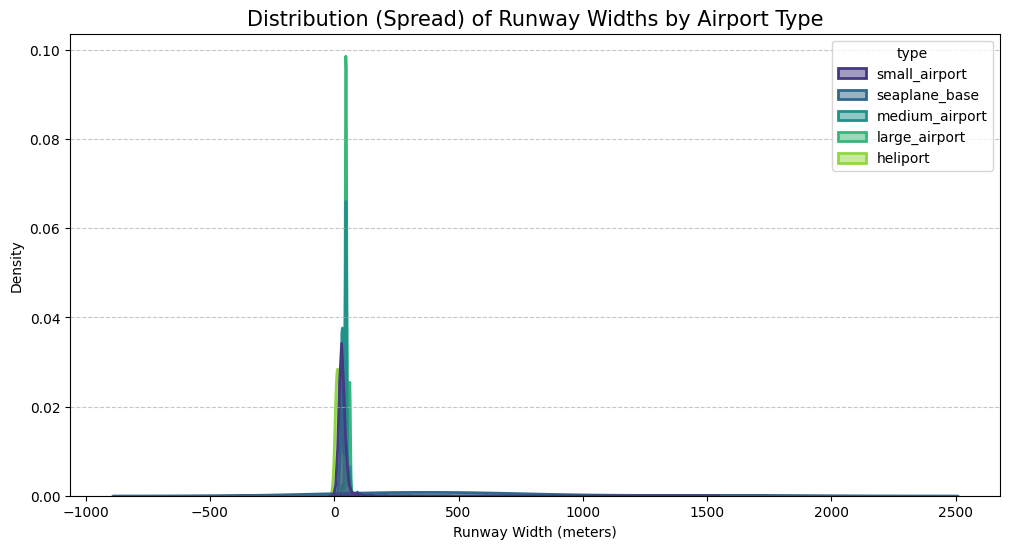

In [ ]:
#Visualising the distribution
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=oa_df,
    x='runway_width_m',
    hue='type',
    fill=True,
    common_norm=False,
    palette='viridis',
    alpha=.5,
    linewidth=2
)
plt.title('Distribution (Spread) of Runway Widths by Airport Type', fontsize=15)
plt.xlabel('Runway Width (meters)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on the statistics and line graph of the spread of values of runway widths, it is noted that 'seaplane_base' and 'small_airport' types have some very extreme values, which does not make sense. Small airport and seaplane bases serve small aircraft, hence should not have runway widths wider than medium and large airports.

The extreme values could likely be that unlike large commercial airports, the way of measuring runway widths become more loose. For seaplane bases, it could be that the entire water body that the seaplane base is located in, is counted as the runway width. For the small airports, the entire grass field that the runway grass strip is a part of, may be counted as the runway width. Or, it could just be a case of typo errors

Hence, the next section deals with cleaning up the extreme values for small airport rows. As for seaplane bases, since there are only 7 rows, and very rare, I will drop them from the data set

In [ ]:
#Dropping 'seaplane bases' from dataframe
oa_df = oa_df[oa_df['type'] != 'seaplane_base']

In [ ]:
oa_df.shape

(9600, 15)

In [ ]:
#Taking a look at some extreme values of small airports

small_airports = oa_df[oa_df['type'] == 'small_airport']

#Sorting by top 10
top_10_small = small_airports.sort_values(by='runway_width_m', ascending=False).head(10)

print("Top 10 Small Airports by Runway Width:")
print(top_10_small[['name', 'runway_width_m', 'runway_length_m']])

Top 10 Small Airports by Runway Width:
                               name  runway_width_m  runway_length_m
9133             Kulik Lake Airport       1524.0000        1524.0000
9201              Napaskiak Airport        609.6000        4572.0000
9111               Shageluk Airport        304.8000        1524.0000
2075        Szczecin-Dąbie Airfield        251.7648         813.2064
7207                 Gyúró Airfield        199.9488         850.0872
7459                Skuteč Airfield        199.9488         878.1288
2048         Kielce-Masłów Airfield        199.9488         899.7696
2043  Grudziądz Lisie Kąty Airfield        199.9488        1059.7896
7397     Jindřichův Hradec Airfield        199.9488         699.8208
7399               Jihlava Airfield        160.0200         919.8864


In [ ]:
#Because the values of small airport widths are heavily clustered around a standard width,
#to use a higher percentile like between 95% or 99% to find the max limit of runway widths

cap_value1 = small_airports['runway_width_m'].quantile(0.99)
cap_value2 = small_airports['runway_width_m'].quantile(0.98)
cap_value3 = small_airports['runway_width_m'].quantile(0.97)
cap_value4 = small_airports['runway_width_m'].quantile(0.96)
cap_value5 = small_airports['runway_width_m'].quantile(0.95)

print(f"99th Percentile Cap for Small Airports: {cap_value1:.2f}m")
print(f"98th Percentile Cap for Small Airports: {cap_value2:.2f}m")
print(f"97th Percentile Cap for Small Airports: {cap_value3:.2f}m")
print(f"96th Percentile Cap for Small Airports: {cap_value4:.2f}m")
print(f"95th Percentile Cap for Small Airports: {cap_value5:.2f}m")

99th Percentile Cap for Small Airports: 107.68m
98th Percentile Cap for Small Airports: 90.59m
97th Percentile Cap for Small Airports: 76.20m
96th Percentile Cap for Small Airports: 60.96m
95th Percentile Cap for Small Airports: 57.91m


In [ ]:
#To use 99th percentile on a subset dataframe and verify values first

small_airports = oa_df[oa_df['type'] == 'small_airport'].copy()

upper_cap = small_airports['runway_width_m'].quantile(0.99)

print(f"Applying 99th Percentile Cap for Small Airports...")
print(f"99% of small airports are narrower than: {upper_cap:.2f}m")

#Replace anything above the cap with the cap value itself
small_airports['runway_width_m'] = np.where(
    small_airports['runway_width_m'] > upper_cap,
    upper_cap,
    small_airports['runway_width_m']
)

#Look at the new range of values
print("New Range of Values for Small Airports:")
print(small_airports['runway_width_m'].agg(['min', 'max', 'mean', 'std']))

Applying 99th Percentile Cap for Small Airports...
99% of small airports are narrower than: 107.68m
New Range of Values for Small Airports:
min       3.048000
max     107.679744
mean     31.821408
std      15.228146
Name: runway_width_m, dtype: float64


In [ ]:
#Now after confirming that the ranges are less extreme, to add back changes to the main dataframe

#Use .loc and the index of the subset to update the original rows of the main dataframe accurately
oa_df.loc[small_airports.index, 'runway_width_m'] = small_airports['runway_width_m']

#Recalculate 'runway area' for these airports, since runway area is derived from multiplying width and length
# This ensures your 'target' variable is also updated with the cleaned data
oa_df['runway_area_m2'] = oa_df['runway_length_m'] * oa_df['runway_width_m']

#Check the top 10 again to verify they are now capped
print("Top 10 Small Airports (After Capping)")
print(oa_df[oa_df['type'] == 'small_airport'].sort_values('runway_width_m', ascending=False).head(10)[['name', 'runway_width_m']])

Top 10 Small Airports (After Capping)
                               name  runway_width_m
2043  Grudziądz Lisie Kąty Airfield      107.679744
9201              Napaskiak Airport      107.679744
9045            Scammon Bay Airport      107.679744
9133             Kulik Lake Airport      107.679744
7459                Skuteč Airfield      107.679744
2075        Szczecin-Dąbie Airfield      107.679744
7402                Kladno Airfield      107.679744
7207                 Gyúró Airfield      107.679744
7414                 Kyjov Airfield      107.679744
1289          Saint Hubert Airfield      107.679744


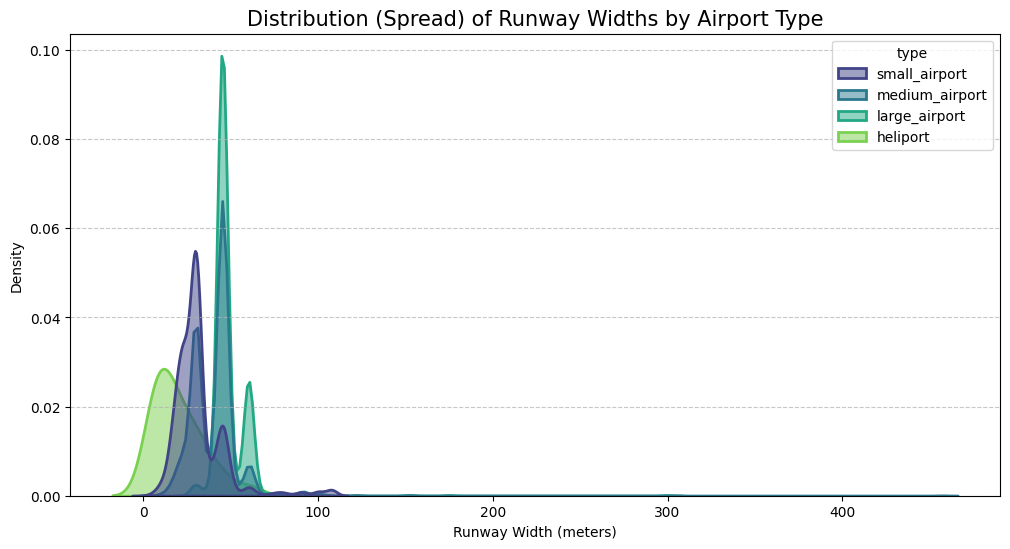

In [ ]:
#Visualising the capped distribution now of the 4 types remaining
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=oa_df,
    x='runway_width_m',
    hue='type',
    fill=True,
    common_norm=False,
    palette='viridis',
    alpha=.5,
    linewidth=2
)
plt.title('Distribution (Spread) of Runway Widths by Airport Type', fontsize=15)
plt.xlabel('Runway Width (meters)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Even after managing extreme values, the values are not spread out nicely over a normal distribution curve
#Hence, it is better to use median values to impute

#Looking at the number of nulls again - this is the number of rows that will be imputed with the median value
oa_df['runway_width_m'].isnull().sum()

np.int64(2528)

In [ ]:
#Imputing the median values of airport types to the null values of runway width
medians_per_type = oa_df.groupby('type')['runway_width_m'].median()
print("Median widths used for imputation:")
print(medians_per_type)

# transform('median') creates a series of the same length as the dataframe
oa_df['runway_width_m'] = oa_df['runway_width_m'].fillna(
    oa_df.groupby('type')['runway_width_m'].transform('median')
)

#Verification
remaining_nulls = oa_df['runway_width_m'].isnull().sum()
print(f"Remaining nulls in runway width: {remaining_nulls}")

Median widths used for imputation:
type
heliport          16.9164
large_airport     45.1104
medium_airport    45.1104
small_airport     29.8704
Name: runway_width_m, dtype: float64
Remaining nulls in runway width: 0


In [ ]:
#Confirming that there are no more nulls
oa_df['runway_width_m'].isnull().sum()

np.int64(0)

In [ ]:
#Going back to the original issue, that is null runway area values, to now multiple the runway widths with the runway lengths to get the runway areas in square meters and kilometers

oa_df['runway_area_m2'] = oa_df['runway_length_m'] * oa_df['runway_width_m']
oa_df['runway_area_km2'] = oa_df['runway_area_m2'] / 1000000


In [ ]:
#Checking how many runway area values are still having nulls
oa_df['runway_area_km2'].isnull().sum()

np.int64(1766)

In [ ]:
oa_df[oa_df['runway_area_km2'].isnull()].head(20)

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2
0,SO,Somalia,Adado,Adado Airport,small_airport,AAD,HCAD,AAD,6.095802,46.637500,305.1048,NaN,29.8704,NaN,NaN
1,SA,Saudi Arabia,Batha,Batha Airport,small_airport,AE-0001,OEBT,NaN,24.214693,51.449890,78.3336,NaN,29.8704,NaN,NaN
2,AF,Afghanistan,Kara Tapa,Toorghodi Heliport,heliport,AF-0019,OATD,NaN,35.222198,62.290600,792.4800,NaN,16.9164,NaN,NaN
4,AF,Afghanistan,NaN,Logar Airport,small_airport,AF-0021,OALG,NaN,33.986500,69.023102,1930.2984,NaN,29.8704,NaN,NaN
5,AF,Afghanistan,Muqur,Muqur Airport,small_airport,AF-0023,OAMK,NaN,32.879601,67.848602,2011.6800,NaN,29.8704,NaN,NaN
12,SB,Solomon Islands,Barakoma,Barakoma Airport,small_airport,AGBA,AGBA,VEV,-7.912780,156.705994,NaN,NaN,29.8704,NaN,NaN
34,SB,Solomon Islands,Yandina,Yandina Airport,small_airport,AGGY,AGGY,XYA,-9.092816,159.218410,18.2880,NaN,29.8704,NaN,NaN
35,SB,Solomon Islands,Veravaulo,Isuna Heliport,heliport,AGIN,AGIN,NaN,-9.805809,159.962722,7.9248,NaN,16.9164,NaN,NaN
41,SB,Solomon Islands,Manaoba,Manaoba Airport,small_airport,AGOB,AGOB,MHM,-8.325008,160.800510,4.2672,NaN,29.8704,NaN,NaN
45,SB,Solomon Islands,Tulaghi Island,Tulaghi Heliport,heliport,AGTI,AGTI,TLG,-9.108000,160.149167,0.9144,NaN,16.9164,NaN,NaN


In [ ]:
#Similarly, runway area values are empty because of empty runway lengths values
#Checking for how many null values are there for runway lengths

oa_df['runway_length_m'].isnull().sum()

np.int64(1766)

In [ ]:
#Looking at some basic statistics of runway lengths by airport types
oa_df.groupby('type')['runway_length_m'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
heliport,27.0,383.799644,685.605161,4.8768,8.9916,29.8704,343.3572,2742.5904
large_airport,1165.0,3053.170612,604.359015,599.8464,2619.7560,3019.0440,3500.0184,4999.9392
medium_airport,3398.0,2105.530772,714.055630,399.8976,1525.6002,2005.5840,2539.3650,4999.9392
small_airport,3244.0,1321.894023,598.017863,0.0000,900.0744,1219.2000,1615.5162,4572.0000


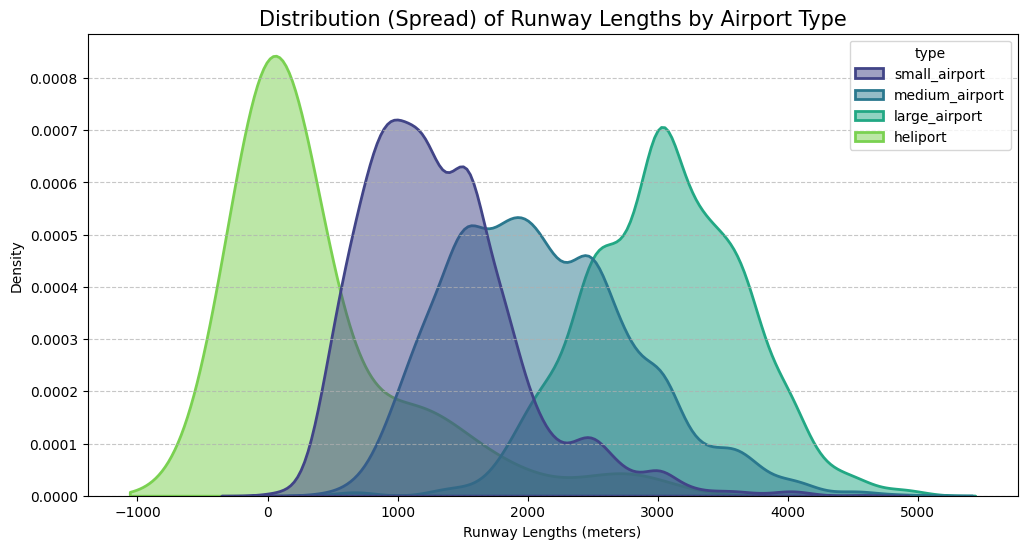

In [ ]:
#Visualising the distribution of runway lengths by airport type as well
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=oa_df,
    x='runway_length_m',
    hue='type',
    fill=True,
    common_norm=False,
    palette='viridis',
    alpha=.5,
    linewidth=2
)
plt.title('Distribution (Spread) of Runway Lengths by Airport Type', fontsize=15)
plt.xlabel('Runway Lengths (meters)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Since runway lengths follow a clear normal distribution pattern, will use the means for imputation

#Checking the mean values of airport types to the null values of runway lengths
mean_per_type = oa_df.groupby('type')['runway_length_m'].mean().sort_values(ascending=False)
print("Mean lengths used for imputation:")
print(mean_per_type)

Mean lengths used for imputation:
type
large_airport     3053.170612
medium_airport    2105.530772
small_airport     1321.894023
heliport           383.799644
Name: runway_length_m, dtype: float64


In [ ]:
#The mean values make sense, so now imputing them to the main dataframe
#transform('mean') creates a series of the same length as the dataframe
oa_df['runway_length_m'] = oa_df['runway_length_m'].fillna(
    oa_df.groupby('type')['runway_length_m'].transform('mean')
)

In [ ]:
#Again, going back to null runway area values, to now multiple the runway widths with the runway lengths to get the runway areas in square meters and kilometers

oa_df['runway_area_m2'] = oa_df['runway_length_m'] * oa_df['runway_width_m']
oa_df['runway_area_km2'] = oa_df['runway_area_m2'] / 1000000

In [ ]:
#Checking for nulls again for runway related measures
oa_df.isnull().sum()

iso_country          92
country_name          0
municipality        444
name                  0
type                  0
ident                 0
icao_code             0
iata_code          1912
latitude_deg          0
longitude_deg         0
airport_elev_m      246
runway_length_m       0
runway_width_m        0
runway_area_m2        0
runway_area_km2       0
dtype: int64

Next, another important feature is airport elevation. How high an airport is located at, directly affects how long a runway needs to be. Hence, I would prefer if there are no null values for this measure too

In [ ]:
oa_df[oa_df['airport_elev_m'].isnull()]

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2
12727,CN,China,Yan'an (Baota),Yan'an Nanniwan Airport,medium_airport,ZLYA,ZLYA,ENY,36.479413,109.464083,NaN,3000.146400,60.9600,182888.924544,0.182889
12659,CN,China,Jieyang (Rongcheng),Jieyang Chaoshan International Airport,medium_airport,ZGOW,ZGOW,SWA,23.552000,116.503300,NaN,3200.095200,45.1104,144357.574510,0.144358
12048,YE,Yemen,Mokha,Mokha International Airport,large_airport,YE-0012,OYMK,NaN,13.296941,43.231858,NaN,3000.146400,45.1104,135337.804163,0.135338
12605,CN,China,Chengde,Chengde Puning Airport,medium_airport,ZBCD,ZBCD,CDE,41.122500,118.073889,NaN,2799.892800,45.1104,126304.284165,0.126304
12888,CN,China,Aral,Aral Tarim Airport,small_airport,ZWAL,ZWAL,ACF,40.434748,81.262060,NaN,2799.892800,45.1104,126304.284165,0.126304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12912,CN,China,Anshan,Anshan Teng'ao Airport / Anshan Air Base,medium_airport,ZYAS,ZYAS,AOG,41.105301,122.853996,NaN,2599.944000,45.1104,117284.513818,0.117285
12926,CN,China,Jilin,Jilin Ertaizi Airport,small_airport,ZYJL,ZYJL,JIL,44.002652,126.395244,NaN,1321.894023,29.8704,39485.503230,0.039486
12928,CN,China,Jiansanjiang,Jiansanjiang Shidi Airport,medium_airport,ZYJS,ZYJS,JSJ,47.108248,132.657920,NaN,2499.969600,45.1104,112774.628644,0.112775
12930,CN,China,Jinzhou (Linghai),Jinzhou Bay Airport,medium_airport,ZYJZ,ZYJZ,JNZ,40.936032,121.277114,NaN,2499.969600,45.1104,112774.628644,0.112775


In [ ]:
len(oa_df[oa_df['airport_elev_m'].isnull()]['ident'].unique())

246

In [ ]:
#Printing the ident of these airports
oa_df[oa_df['airport_elev_m'].isnull()]['ident'].unique()

array(['ZLYA', 'ZGOW', 'YE-0012', 'ZBCD', 'ZWAL', 'ZLDH', 'ZLQY', 'ZBHZ',
       'ZBSG', 'ZHSY', 'ZSTX', 'ZPJM', 'ZPCW', 'ZYFY', 'ZWYN', 'ZWTC',
       'YYOR', 'WPOC', 'VIKG', 'YMIR', 'ZULB', 'DNFB', 'ETWM', 'ESGM',
       'HU-0033', 'ESGC', 'AGEV', 'AGRC', 'AGGC', 'AGGP', 'IN-0074',
       'AGGI', 'AGAT', 'EELM', 'US-12783', 'AGBA', 'AGGS', 'AGRM',
       'AU-0177', 'AU-0785', 'AU-0796', 'AZ-0003', 'AZ-0004', 'AZ-0010',
       'AZ-0014', 'AZ-0017', 'BA-0002', 'BG-0025', 'BG-0031', 'BGSO',
       'BS-0003', 'BW-0036', 'CN-0359', 'CN-0413', 'CN-0417', 'CN-0421',
       'CN-0422', 'CZ-0161', 'DK-0012', 'EHDV', 'EHTS', 'EKAF', 'EKAN',
       'EKAR', 'ENFB', 'EPBB', 'EPGE', 'ES-0366', 'ESGD', 'ESGH', 'ESVM',
       'ETEB', 'EVLU', 'EYIG', 'FBXG', 'FDUB', 'FNCF', 'FNCV', 'FYAI',
       'FZFU', 'FZOC', 'GB-1327', 'GGBU', 'GR-0015', 'HDMO', 'HHAG',
       'HKNY', 'HU-0080', 'IQ-0052', 'IT-0653', 'JO-0001', 'LBSV', 'LIRH',
       'LOAI', 'LOJD', 'LRWG', 'LSVD', 'LSVP', 'LSVV', 'LSYI', 'LSYK',


For elevation, 'airport type' cannot be used as there is no logical relationship between these 2 measures. Instead, the closest available features are 'latitude' and 'longitude'. Latitude and longitudes are specific places on the Earth, hence direct averages cannot be used as an approximate. Rather, a method called 'KNN Imputer' is a better way to find similar groups of locations on Earth, which is a better approximate to find the airport's elevation

In [ ]:
#Handing nulls of airport elevation by imputing the 'KNN Imputer' methods
#which takes the 'k' most similar rows in the existing oa_df dataset and averages the values

from sklearn.impute import KNNImputer

#Choose the lat/lon columns to "inform" the imputer about the elevation
impute_cols = ['latitude_deg', 'longitude_deg', 'airport_elev_m']

#Initialize the imputer (looking at the 5 nearest neighbors)
#'weights' gives more importance to closer points
imputer = KNNImputer(n_neighbors=5, weights='distance')

#Create a temporary array of imputed values
imputed_array = imputer.fit_transform(oa_df[impute_cols])
imputed_df = pd.DataFrame(imputed_array, columns=impute_cols, index=oa_df.index)

#Extract the newly calculated elevations, and add it in as a new column in the oa_df dataframe
oa_df['imputed_elevation_m'] = imputed_df['airport_elev_m']

In [ ]:
#Doing a random check on an airport, to confirm if the imputed elevation is more or less accurate to the actual airport's elevation
oa_df[oa_df['ident'] == 'ZYJS']

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2,imputed_elevation_m
12928,CN,China,Jiansanjiang,Jiansanjiang Shidi Airport,medium_airport,ZYJS,ZYJS,JSJ,47.108248,132.65792,NaN,2499.9696,45.1104,112774.628644,0.112775,199.008656


In [ ]:
oa_df[oa_df['ident'] == 'YE-0012']

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2,imputed_elevation_m
12048,YE,Yemen,Mokha,Mokha International Airport,large_airport,YE-0012,OYMK,NaN,13.296941,43.231858,NaN,3000.1464,45.1104,135337.804163,0.135338,308.061566


In [ ]:
oa_df[oa_df['ident'] == 'YFLO']

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2,imputed_elevation_m
12071,AU,Australia,NaN,Flora Valley Airport,small_airport,YFLO,YFLO,FVL,-18.297844,128.455897,NaN,1321.894023,29.8704,39485.50323,0.039486,288.867724


Double checking against actual elevations of these airports:

*   Jiansanjiang Shidi Airport is at 368m elevation (vs 199m imputed)
*   Mokha International Airport	is at around 500m (vs 308m imputed)
*   Flora Valley Airport is at around 374m (vs 288m imputed)

In [ ]:
#Doing some simple statistic tests, to ensure that the imputed values did not significantly change the 'structure' of the values after imputation

#1st check: Comparing the mean of 'airport_elev_m' versus 'imputed_elevation_m' columns

#Calculate means
original_mean = oa_df['airport_elev_m'].mean()
imputed_mean = oa_df['imputed_elevation_m'].mean()

#Calculate difference and percentage change
diff = imputed_mean - original_mean
pct_change = (diff / original_mean) * 100

print(f"Original Mean Elevation: {original_mean:.2f} m")
print(f"Imputed Mean Elevation: {imputed_mean:.2f} m")
print(f"Absolute Difference:     {diff:.2f} m")
print(f"Percentage Change:      {pct_change:.2f}%")

Original Mean Elevation: 366.63 m
Elevated Mean Elevation: 365.02 m
Absolute Difference:     -1.61 m
Percentage Change:      -0.44%


C:\Users\chery\AppData\Local\Temp\ipykernel_12560\3542270729.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Version', y='Elevation', data=plot_data, palette='Pastel1')


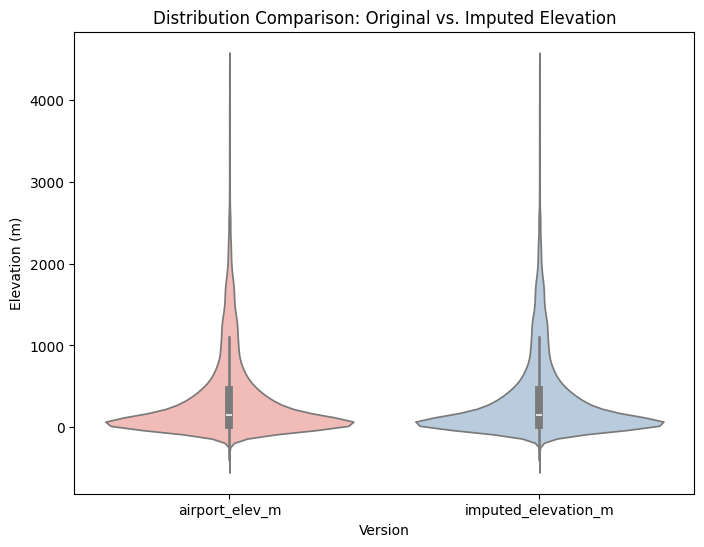

In [ ]:
#2nd check: Looking at violin plots to see the 'shape' of the values

plot_data = oa_df[['airport_elev_m', 'imputed_elevation_m']].melt()
plot_data.columns = ['Version', 'Elevation']

plt.figure(figsize=(8, 6))
sns.violinplot(x='Version', y='Elevation', data=plot_data, palette='Pastel1')
plt.title('Distribution Comparison: Original vs. Imputed Elevation')
plt.ylabel('Elevation (m)')
plt.show()

In [ ]:
#3rd check: use T-test and P-value, which are statistics methods to
#check if the 'center' of the data was changed significantly

from scipy import stats

#Drop nulls
comparison_df = oa_df[['airport_elev_m', 'imputed_elevation_m']].dropna()

t_stat, p_val = stats.ttest_rel(comparison_df['airport_elev_m'],
                                comparison_df['imputed_elevation_m'])

print(f"T-statistic: {t_stat:.5f}")
print(f"P-value:     {p_val:.5f}")

if p_val < 0.05:
    print("Result: Significant difference found between the two versions.")
else:
    print("Result: No statistically significant difference in the means.")

T-statistic: nan
P-value:     nan
Result: No statistically significant difference in the means.


In [ ]:
#Since there is no significant difference, to overwrite the original elevation column with the new imputed column, and drop the imputed column

oa_df['airport_elev_m'] = oa_df['imputed_elevation_m']
oa_df.drop(columns=['imputed_elevation_m'], inplace=True)

In [ ]:
#Checking for nulls to confirm that all elevation have been imputed
oa_df.isnull().sum()


iso_country          92
country_name          0
municipality        444
name                  0
type                  0
ident                 0
icao_code             0
iata_code          1912
latitude_deg          0
longitude_deg         0
airport_elev_m        0
runway_length_m       0
runway_width_m        0
runway_area_m2        0
runway_area_km2       0
dtype: int64

Finally, doing a sense check on the airport dataset countries and territories included

In [ ]:
#Doing a sense check on how many unique countries there are now
print(f"Total countries in Airport data: {len(set(oa_df['iso_country'].unique()))}")

Total countries in Airport data: 239


In [ ]:
np.sort(oa_df['country_name'].unique())

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Angola',
       'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Caribbean Netherlands', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Chile', 'China',
       'Christmas Island', 'Cocos (Keeling) Islands', 'Colombia',
       'Comoros', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba',
       'Curaçao', 'Cyprus', 'Czech Republic', "Côte d'Ivoire",
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial

In [ ]:
#Doing a sense check on the countries have the most airports in the above dataframe, to see if the data looks right
print(oa_df['iso_country'].value_counts().head(10))

iso_country
US    1737
AU     545
CA     363
PG     295
CN     288
BR     287
RU     208
CD     202
ID     191
DE     183
Name: count, dtype: int64


In [ ]:
oa_df.shape

(9600, 15)

In [ ]:
oa_df[oa_df['iso_country'].isnull()]

,iso_country,country_name,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2
3005,NaN,Namibia,Walvis Bay(Rooikop),Walvis Bay International Airport,large_airport,FYWB,FYWB,WVB,-22.979332,14.647102,91.1352,3500.018400,59.7408,209093.899231,0.209094
3008,NaN,Namibia,Windhoek,Hosea Kutako International Airport,large_airport,FYWH,FYWH,WDH,-22.479900,17.470900,1719.0720,4575.048000,45.1104,206382.245299,0.206382
2947,NaN,Namibia,Grootfontein,Grootfontein Airport,medium_airport,FYGF,FYGF,GFY,-19.602200,18.122700,1413.0528,3560.064000,45.1104,160595.911066,0.160596
2958,NaN,Namibia,Keetmanshoop,Keetmanshoop Airport,medium_airport,FYKT,FYKT,KMP,-26.539801,18.111401,1068.6288,2315.870400,45.1104,104469.840092,0.104470
2994,NaN,Namibia,Rundu,Rundu Airport,medium_airport,FYRU,FYRU,NDU,-17.956499,19.719400,1105.5096,3354.019200,29.8704,100185.895112,0.100186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8285,NaN,Namibia,NaN,Okamapu Landing Site,small_airport,NA-0149,FYMP,NaN,-21.745815,17.887208,1688.8968,1321.894023,29.8704,39485.503230,0.039486
8286,NaN,Namibia,Khorixas,Khorixas Airport,small_airport,NA-0159,FYKX,NaN,-20.366192,15.059298,1021.9944,1321.894023,29.8704,39485.503230,0.039486
8287,NaN,Namibia,Okaongwati,Okangwati Airport,small_airport,NA-0160,FYKW,NaN,-17.438730,13.278200,1083.5640,1321.894023,29.8704,39485.503230,0.039486
8288,NaN,Namibia,Ehomba,Ehomba Airport,small_airport,NA-0169,FYEH,NaN,-17.488000,13.836836,1090.5744,1321.894023,29.8704,39485.503230,0.039486


In [ ]:
#Checking how many unique countries are there with null iso_country values
len(oa_df[oa_df['iso_country'].isnull()]['country_name'].unique())


1

In [ ]:
#This means that only Namibia is having this null issue
#Since Namibia's 2-letter ISO country code is 'NA', it is being misinterpreted as being a 'null' value
#For this dataframe, to impute 'NM' to 'Namibia' , since there is no other country with that code

oa_df.loc[oa_df['iso_country'].isnull(), 'iso_country'] = 'NM'

In [ ]:
#Renaming 'country_code' to 'country_code_oa' for ease of cross-checking with World Bank's countries later on
oa_df.rename(columns={'country_name': 'country_name_oa'}, inplace=True)

In [ ]:
#Checking for nulls to confirm that missing names have been imputed
##The column 'municipality' and 'iata_code' will not be used later on
oa_df.isnull().sum()

iso_country           0
country_name_oa       0
municipality        444
name                  0
type                  0
ident                 0
icao_code             0
iata_code          1912
latitude_deg          0
longitude_deg         0
airport_elev_m        0
runway_length_m       0
runway_width_m        0
runway_area_m2        0
runway_area_km2       0
dtype: int64

Since the columns 'municipality' and 'iata_code' are not going to be used in the final dataframe, the data cleaning for oa_df is completed

In [ ]:
#Saving dataframe out as csv
oa_df.to_csv('oa_df.csv', index=False)

<h3> 3 City Temperature (Dim Table 2) 🌡📈

Using WorldClim data found at this link https://www.worldclim.org/data/monthlywth.html , to get the average temperature of the cities that appear in the Geonames cities dataframe

Like elevation, a city's daily temperatures and long-term climate affects how long a runway needs to be built. The higher the temperature, the longer a runway needs to be, to allow for more breaking distance for an aircraft
The reason a city's temperature is used instead of an existing airport's temperature is used is because, an airport may be built in a city that has a very different climate from the country's main airport, or even from the closest airport, if the city is very remote. This may be the case, especially for smaller cities that are located far away from the main airport

About rasterio library

The files from WorldClim are in .tif (Geotiff) format, containing with what is called "raster data". Raster data is basically a digital 'photograph made up 'pixels'. Instead of colours, these pixels contain temperature information in this case. Pixels are mapped to regions on the Earth's surface, which forms a spatial bounding box

The "rasterio" library handles the math that converts lat/lon coordinates into
specifc 'pixel' rows and columns

In [ ]:
pip install rasterio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import rasterio
import glob
import os

In [ ]:
#This creates a list of coordinate pairs that are only relevant for this data pull (those of the cities lat&lon from city_df)
#instead of the whole world
#rasterio librbary requires it to be in this order - (lon, lat)
coords = list(zip(city_df['city_lon'], city_df['city_lat']))

#Setting up the .tif files
tmax_files = sorted(glob.glob('WorldClim Geotiff files 2023/*tmax*.tif'))
tmin_files = sorted(glob.glob('WorldClim Geotiff files 2023/*tmin*.tif'))

#Extracts pixel values (the spatial bounding boxes) for all coords across the list of monthly files
def extract_from_rasters(file_list, coords):
    results = []
    for file in file_list:
        print(f"Processing: {os.path.basename(file)}")
        #'.open()' opens up the various files as a global map
        with rasterio.open(file) as src:
            #'.sample()' only picks up the specific coordinates, out of the whole map
            sampled_values = [val[0] for val in src.sample(coords)]
            results.append(sampled_values)
    return np.array(results) #Shape: (12 months, 26000+ cities)

#Extracting all the temperature values into a NumPy array,
#where rows are months, and columns are cities
print("Extracting Max Temperatures...")
tmax_matrix = extract_from_rasters(tmax_files, coords)

print("Extracting Min Temperatures...")
tmin_matrix = extract_from_rasters(tmin_files, coords)

#Calculating the temperature values
  #Annual Max: The highest value recorded in any month
annual_max = np.max(tmax_matrix, axis=0)

  #Monthly Mean: (Tmin + Tmax) / 2 for each month
monthly_means = (tmin_matrix + tmax_matrix) / 2

  #Annual Mean: Average of those 12 monthly means
annual_mean = np.mean(monthly_means, axis=0)

#Consolidate into weather_df
weather_df = pd.DataFrame({
    'city_id': city_df['geonames_id'],
    'city_name': city_df['city_name'],
    'worldclim_avg_temp': annual_mean,
    'worldclim_max_temp': annual_max
})

#9999 is returned when there is no value found for that coordinate
#Just in case that happens, to convert to null value
weather_df.replace(-9999, np.nan, inplace=True)

print("Done! Weather data consolidated.")

Extracting Max Temperatures...
Processing: wc2.1_cruts4.09_5m_tmax_2023-01.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-02.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-03.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-04.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-05.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-06.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-07.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-08.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-09.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-10.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-11.tif
Processing: wc2.1_cruts4.09_5m_tmax_2023-12.tif
Extracting Min Temperatures...
Processing: wc2.1_cruts4.09_5m_tmin_2023-01.tif
Processing: wc2.1_cruts4.09_5m_tmin_2023-02.tif
Processing: wc2.1_cruts4.09_5m_tmin_2023-03.tif
Processing: wc2.1_cruts4.09_5m_tmin_2023-04.tif
Processing: wc2.1_cruts4.09_5m_tmin_2023-05.tif
Processing: wc2.1_cruts4.09_5m_tmin_2023-06.tif
Processing: wc2.1_cruts4.09_5m_tmin_2023-07.tif
Processing: wc2.1_cruts4.0

In [ ]:
weather_df.shape

(26093, 4)

In [ ]:
#Renaming columns
weather_df = weather_df.rename(columns={'worldclim_avg_temp': 'city_avg_temp', 'worldclim_max_temp' : 'city_max_temp'})

In [ ]:
weather_df.head()

,city_id,city_name,city_avg_temp,city_max_temp
25978,3367877,Franschhoek,15.718750,27.50
23411,4714149,New Caney,21.822916,37.75
3271,6162703,Templeton-Est,8.114583,28.25
17620,12625526,Tropicana Indah,28.489584,34.00
9303,2645420,Kingswinford,10.677083,22.00


After doing some random checks on the city temperatures, I can verify that the data is reliable and accurate

In [ ]:
#Checking for any nulls
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26093 entries, 25978 to 25564
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city_id        26093 non-null  object 
 1   city_name      26093 non-null  object 
 2   city_avg_temp  26053 non-null  float32
 3   city_max_temp  26053 non-null  float32
dtypes: float32(2), object(2)
memory usage: 815.4+ KB


In [ ]:
weather_df.to_csv('weather_df.csv', index=False)

<h3> 4 Country GDP & Population 🗺💰 (Dim Table )

Pulling most recent country-level GDP and population indicators data from the World Bank API


In [ ]:
#Loading World Bank-specific Libraries
!pip install wbgapi
import wbgapi as wb


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Selected indicators as per World Bank with respective indicator codes below
my_wb_indicators = {
'NY.GDP.MKTP.CD' : 'GDP (current US$)',
'NY.GDP.PCAP.CD' : 'GDP per capita (Current US$)',
'SP.POP.TOTL' : 'Population, total',
'EN.POP.DNST' : 'Population density (per sq km)',
'IS.AIR.PSGR' : 'Air transport, passengers carried'
}

#Calling the API using the wbgapi library package, which simplifies manual API calling via HTTP
wb_df = wb.data.DataFrame(my_wb_indicators.keys(),
                          economy='all', #This pulls all countries' data
                          time=2023,     #This pulls data specifically for 2023
                          labels=True)   #This adds country names automatically which we need for easier verification later on

wb_df = wb_df.rename(columns=my_wb_indicators)
wb_df.index.name = 'iso_country_3'

#Convert units to larger units like millions and billions
wb_df['country_GDP($b)'] = wb_df['GDP (current US$)'] / 1000000000
wb_df['country_GDPcap($000s)'] = wb_df['GDP per capita (Current US$)'] / 1000
wb_df['country_pop(m)'] = wb_df['Population, total'] / 1000000
wb_df['country_popden_persqkm'] = wb_df['Population density (per sq km)']
wb_df['air_passengers(m)'] = wb_df['Air transport, passengers carried'] / 1000000

#Reset index
wb_df = wb_df.reset_index()

In [ ]:
wb_df.head(10)

,iso_country_3,Country,Population density (per sq km),"Air transport, passengers carried",GDP (current US$),GDP per capita (Current US$),"Population, total",country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
0,ZWE,Zimbabwe,42.240719,9.249438e+04,3.587178e+10,2195.224921,16340822.0,35.871780,2.195225,16.340822,42.240719,0.092494
1,ZMB,Zambia,27.877648,3.217388e+05,2.757796e+10,1330.727806,20723965.0,27.577956,1.330728,20.723965,27.877648,0.321739
2,YEM,"Yemen, Rep.",74.608025,6.186130e+05,NaN,NaN,39390799.0,NaN,NaN,39.390799,74.608025,0.618613
3,PSE,West Bank and Gaza,857.390041,NaN,1.784790e+10,3455.028529,5165775.0,17.847900,3.455029,5.165775,857.390041,NaN
4,VIR,Virgin Islands (U.S.),299.762857,NaN,NaN,NaN,104917.0,NaN,NaN,0.104917,299.762857,NaN
5,VNM,Viet Nam,320.175198,5.511483e+07,4.338577e+11,4323.350320,100352192.0,433.857681,4.323350,100.352192,320.175198,55.114832
6,VEN,"Venezuela, RB",32.085317,1.783667e+06,1.023765e+11,3617.435946,28300854.0,102.376527,3.617436,28.300854,32.085317,1.783667
7,VUT,Vanuatu,26.284578,3.592900e+05,1.115861e+09,3482.614582,320409.0,1.115861,3.482615,0.320409,26.284578,0.359290
8,UZB,Uzbekistan,80.908447,4.849939e+06,1.026419e+11,2878.968793,35652307.0,102.641879,2.878969,35.652307,80.908447,4.849939
9,URY,Uruguay,19.358250,NaN,7.799167e+10,23019.422156,3388081.0,77.991667,23.019422,3.388081,19.358250,NaN


In [ ]:
#Dropping original columns & Renaming
wb_df.drop(columns=['Population density (per sq km)', 'GDP (current US$)', 'GDP per capita (Current US$)',
                    'Population, total', 'Air transport, passengers carried'], inplace=True)

wb_df = wb_df.rename(columns={'Country': 'country_name_wb'})

wb_df.head()


,iso_country_3,country_name_wb,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
0,ZWE,Zimbabwe,35.871780,2.195225,16.340822,42.240719,0.092494
1,ZMB,Zambia,27.577956,1.330728,20.723965,27.877648,0.321739
2,YEM,"Yemen, Rep.",NaN,NaN,39.390799,74.608025,0.618613
3,PSE,West Bank and Gaza,17.847900,3.455029,5.165775,857.390041,NaN
4,VIR,Virgin Islands (U.S.),NaN,NaN,0.104917,299.762857,NaN


In [ ]:
wb_df.shape

(266, 7)

Handling the Country code issue

The World Bank dataframe has ISO 3-letter country code, while the OurAirports dataframe uses ISO 2-letter code. To link up the tables later, to convert the 3-letter country codes to 2-letter codes. There is an existing Python 'pycountry' library to do this


In [ ]:
#Loading pycountry to handle different formats of country codes (eg. 2-letter vs 3-letter)
!pip install pycountry
import pycountry


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Convert 3-letter to 2-letter ISO country code

#'alpha_2' is the syntax to access the 2-letter ISO codes in the pycountry library
#'pycountry.countries' loads the whole library of countries recognised by ISO
#'.get()' searches for the specific entry of 3-letter code
def get_alpha2(alpha3):
    try:
        return pycountry.countries.get(alpha_3=alpha3).alpha_2
    except:
        return "MISSING"

#Add the 2-letter code as a new column
wb_df['iso_2_temp'] = wb_df['iso_country_3'].apply(get_alpha2)

#Create a temporary dataframe for any rows that could not find its 2-letter country code
unconverted = wb_df[wb_df['iso_2_temp'] == "MISSING"].copy()

#Verification
print(f"Total rows in WB data: {len(wb_df)}")
print(f"Rows that failed to convert: {len(unconverted)}")
print("Sample of Unconverted Rows:")
print(unconverted[['iso_country_3', 'country_name_wb']].drop_duplicates())

Total rows in WB data: 266
Rows that failed to convert: 51
Sample of Unconverted Rows:
    iso_country_3                                    country_name_wb
111           XKX                                             Kosovo
177           CHI                                    Channel Islands
217           WLD                                              World
218           UMC                                Upper middle income
219           TSS          Sub-Saharan Africa (IDA & IBRD countries)
220           SSA         Sub-Saharan Africa (excluding high income)
221           SSF                                 Sub-Saharan Africa
222           TSA                            South Asia (IDA & IBRD)
223           SAS                                         South Asia
224           SST                                       Small states
225           PRE                           Pre-demographic dividend
226           PST                          Post-demographic dividend
227           PS

In [ ]:
#Taking a look at row "country_name" == 'WLD'
wb_df[wb_df['iso_country_3'] == 'WLD']

,iso_country_3,country_name_wb,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m),iso_2_temp
217,WLD,World,106741.647821,13.236716,8064.05793,NaN,4268.984474,MISSING


In [ ]:
#'XKX' refers to Kovoso and 'CHI' refers to Channel Islands
#All other unconverted codes are actually world regions,
#which is not the right level of detail (individual countries) for this capstone
#Hence can be dropped from wb_df

wb_df = wb_df[wb_df['iso_2_temp'] != 'MISSING']

In [ ]:
#Checking if there are airports under country name 'Kovoso' and 'Channel Islands' from oa_df
oa_df[oa_df['country_name_oa'].isin(['Kovoso', 'Channel Islands'])]

,iso_country,country_name_oa,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2


In [ ]:
#Since there are none, to drop these 2 rows from the wb_df where iso_country_3 = XKX and CHI
wb_df = wb_df[~wb_df['iso_country_3'].isin(['XKX', 'CHI'])]

In [ ]:
wb_df.shape

(215, 8)

In [ ]:
#Checking for nulls in wb_df
wb_df.isnull().sum()

iso_country_3              0
country_name_wb            0
country_GDP($b)           14
country_GDPcap($000s)     14
country_pop(m)             0
country_popden_persqkm     0
air_passengers(m)         66
iso_2_temp                 0
dtype: int64

In [ ]:
#Taking a look at which are the rows with nulls
wb_df[wb_df['country_GDP($b)'].isnull()]

,iso_country_3,country_name_wb,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m),iso_2_temp
2,YEM,"Yemen, Rep.",NaN,NaN,39.390799,74.608025,0.618613,YE
4,VIR,Virgin Islands (U.S.),NaN,NaN,0.104917,299.762857,NaN,VI
27,SYR,Syrian Arab Republic,NaN,NaN,23.594623,128.490023,0.610745,SY
33,MAF,St. Martin (French part),NaN,NaN,0.027515,550.300000,NaN,MF
38,SSD,South Sudan,NaN,NaN,11.483374,18.171908,NaN,SS
70,MNP,Northern Mariana Islands,NaN,NaN,0.045143,98.136957,NaN,MP
113,PRK,"Korea, Dem. People's Rep.",NaN,NaN,26.418204,219.402076,0.003690,KP
122,IMN,Isle of Man,NaN,NaN,0.084165,147.657895,NaN,IM
137,GUM,Guam,NaN,NaN,0.166506,308.344444,NaN,GU
141,GIB,Gibraltar,NaN,NaN,0.038471,3847.100000,NaN,GI


In [ ]:
import numpy as np
#Printing a list of countries from the above null list
print(np.unique(wb_df[wb_df['country_GDP($b)'].isnull()]['country_name_wb'].values))

['American Samoa' 'British Virgin Islands' 'Cuba' 'Eritrea' 'Gibraltar'
 'Guam' 'Isle of Man' "Korea, Dem. People's Rep."
 'Northern Mariana Islands' 'South Sudan' 'St. Martin (French part)'
 'Syrian Arab Republic' 'Virgin Islands (U.S.)' 'Yemen, Rep.']


In [ ]:
print(np.unique(wb_df[wb_df['country_GDP($b)'].isnull()]['iso_2_temp'].values))

['AS' 'CU' 'ER' 'GI' 'GU' 'IM' 'KP' 'MF' 'MP' 'SS' 'SY' 'VG' 'VI' 'YE']


In [ ]:
#Doing a quick check against oa_df to check if there are airports in these countries/ territories
oa_df[oa_df['iso_country'].isin(['AS' 'CU' 'ER' 'GI' 'GU' 'IM' 'KP' 'MF' 'MP' 'SS' 'SY' 'VG' 'VI' 'YE'])]

,iso_country,country_name_oa,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2


In [ ]:
#Since there are no airports in these countries/territories, to drop those rows from the wb_df
wb_df = wb_df[~wb_df['iso_2_temp'].isin(['AS' 'CU' 'ER' 'GI' 'GU' 'IM' 'KP' 'MF' 'MP' 'SS' 'SY' 'VG' 'VI' 'YE'])]

In [ ]:
wb_df.shape

(215, 8)

In [ ]:
#Saving wb_df out as csv
wb_df.to_csv('wb_df.csv', index=False)

<h3> B.Merging it all together

1. city_df + weather_df = cityweather_df

2. cityweather_df + oa_df = city_weather_airport_df

3. city_weather_airport_df + wb_df = master_df



1. city_df + weather_df = cityweather_df - merging to get the city's average and maximum temperatures

In [ ]:
#1. city_df + weather_df = cityweather_df - simple merging to get the city's
#average and maximum temperatures out of the year 2023

#Ensure that geonames_id are the same data type int first
weather_df['city_id'] = weather_df['city_id'].astype(int)
city_df['geonames_id'] = city_df['geonames_id'].astype(int)

cityweather_df = pd.merge(
    city_df,
    weather_df,
    left_on='geonames_id',
    right_on='city_id',
    how='left'
)

In [ ]:
cityweather_df.head()

,geonames_id,city_name_x,iso_code,city_lat,city_lon,city_pop,city_tier,city_id,city_name_y,city_avg_temp,city_max_temp
0,3367877,Franschhoek,ZA,-33.91075,19.11980,20000,Tier 4,3367877,Franschhoek,15.718750,27.50
1,4714149,New Caney,US,30.15522,-95.21132,20000,Tier 4,4714149,New Caney,21.822916,37.75
2,6162703,Templeton-Est,CA,45.49389,-75.58833,20000,Tier 4,6162703,Templeton-Est,8.114583,28.25
3,12625526,Tropicana Indah,MY,3.14165,101.59089,20000,Tier 4,12625526,Tropicana Indah,28.489584,34.00
4,2645420,Kingswinford,GB,52.49755,-2.16889,20000,Tier 4,2645420,Kingswinford,10.677083,22.00


In [ ]:
#Drop columns
cityweather_df.drop(columns=['city_name_x', 'city_id'], inplace=True)

In [ ]:
#Rename column
cityweather_df.rename(columns={
    'geonames_id': 'city_id',
    'city_name_y': 'city_name',
}, inplace=True)

In [ ]:
cityweather_df.head()

,city_id,iso_code,city_lat,city_lon,city_pop,city_tier,city_name,city_avg_temp,city_max_temp
0,3367877,ZA,-33.91075,19.11980,20000,Tier 4,Franschhoek,15.718750,27.50
1,4714149,US,30.15522,-95.21132,20000,Tier 4,New Caney,21.822916,37.75
2,6162703,CA,45.49389,-75.58833,20000,Tier 4,Templeton-Est,8.114583,28.25
3,12625526,MY,3.14165,101.59089,20000,Tier 4,Tropicana Indah,28.489584,34.00
4,2645420,GB,52.49755,-2.16889,20000,Tier 4,Kingswinford,10.677083,22.00


In [ ]:
cityweather_df.shape

(26093, 9)

In [ ]:
cityweather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26093 entries, 0 to 26092
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city_id        26093 non-null  int64  
 1   iso_code       26093 non-null  object 
 2   city_lat       26093 non-null  float64
 3   city_lon       26093 non-null  float64
 4   city_pop       26093 non-null  int64  
 5   city_tier      26093 non-null  object 
 6   city_name      26093 non-null  object 
 7   city_avg_temp  26053 non-null  float32
 8   city_max_temp  26053 non-null  float32
dtypes: float32(2), float64(2), int64(2), object(3)
memory usage: 1.6+ MB


In [ ]:
#Checking for nulls
cityweather_df.isnull().sum()

city_id           0
iso_code          0
city_lat          0
city_lon          0
city_pop          0
city_tier         0
city_name         0
city_avg_temp    40
city_max_temp    40
dtype: int64

In [ ]:
#Taking a look at the rows with nulls, ie rows that did not managed to match with any of the WorldClim historical records
cityweather_df[cityweather_df['city_avg_temp'].isnull()]

,city_id,iso_code,city_lat,city_lon,city_pop,city_tier,city_name,city_avg_temp,city_max_temp
75,3576812,LC,13.99570,-61.00614,20000,Tier 4,Castries,NaN,NaN
115,108655,SA,26.51959,50.02715,20038,Tier 4,‘Inak,NaN,NaN
1485,3577072,AW,12.53914,-70.02004,21500,Tier 4,Tanki Leendert,NaN,NaN
3800,3577159,AW,12.56596,-70.03198,24193,Tier 4,Noord,NaN,NaN
4537,3477430,BR,-27.15180,-48.48941,25058,Tier 4,Bombinhas,NaN,NaN
4687,9000266,VN,10.51660,108.93292,25267,Tier 4,Phú Quý,NaN,NaN
5452,289174,OM,24.53077,56.56300,26372,Tier 4,Liwá,NaN,NaN
5807,113797,IR,36.57168,52.01530,26947,Tier 4,Nūr,NaN,NaN
7009,3934707,PE,-17.02306,-72.01472,28953,Tier 4,Mollendo,NaN,NaN
7601,3577154,AW,12.52398,-70.02703,29998,Tier 4,Oranjestad,NaN,NaN


In [ ]:
#Removing these 40 rows since the volume compared to 26000+ is negligible
cityweather_df.dropna(inplace=True)

In [ ]:
cityweather_df.shape

(26053, 9)

In [ ]:
cityweather_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26053 entries, 0 to 26092
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city_id        26053 non-null  int64  
 1   iso_code       26053 non-null  object 
 2   city_lat       26053 non-null  float64
 3   city_lon       26053 non-null  float64
 4   city_pop       26053 non-null  int64  
 5   city_tier      26053 non-null  object 
 6   city_name      26053 non-null  object 
 7   city_avg_temp  26053 non-null  float32
 8   city_max_temp  26053 non-null  float32
dtypes: float32(2), float64(2), int64(2), object(3)
memory usage: 1.8+ MB


In [ ]:
#Saving dataframe out as csv
cityweather_df.to_csv('cityweather_df.csv', index=False)

2. cityweather_df + oa_df = city_weather_airport_df

Not every city has an airport. These 2 dataframes cannot be merged directly based on the same key. If merged on country ISO code, only 1 airport of the country can be used, which will greatly reduce the granularity of the airports information. This also reduces runway length (the y target variable) to only 200+ unique values.

Instead, we will be taking the city latitude and longitude and matching them to the nearest airport latitude and longitude to find the 'nearest airport'

In addition, the nearest airport of a city may sometimes be geographically nearer to another country's airport. That should not be the case for this project scope, as each city's is to be tagged to its own country to get the country-level GDP and population in the final dataframe. Hence, the search has to be 'ringfenced' to be within the same country (ISO code)


Before the next section of code, 2 concepts need to be explained.

First, is the concept of 'Haversine Distance'. Because Earth is a sphere, distances are not the same at varying latitudes and longitudes (which has 'degrees' as its unit). As a result, 'nearest neighbours', in terms of finding the nearest airport to a city, cannot be calculated just by straight-line distance using Eucliean distance. Haversine uses angular distances, called radians (the mathematical formula is radians = degrees x 'pi' / 180), to find the equivalent of straight-line distance, which can then be used to find the nearest neighbours

Second, is the concept of 'BallTree'. It is essentially searching for the 'nearest neighbours' in terms of data points, but instead of a flat plane, it searches in a multi-dimensional space. Balltree is a space partitioning data structure for organising points in a multi-dimensional space. It is part of the Scikit-learn library. Because of the same reason stated above, that Earth is a sphere and has a 3D structure (not a flat plane), using an algorithm like BallTree is necessary

In [ ]:
#Importing relevant libraries

from sklearn.neighbors import BallTree

#Defining the function to limit to searching for an airport in the same country
def find_nearest_in_country(city_group_df, airport_source_df):
    #Identify current country code from the group
    #(just looks at the first row [0] since it is the same country in that group)
    country_code = city_group_df['iso_code'].iloc[0]

    #Filter for the list of airports based on 2-letter ISO code for the current country
    country_airports_df = airport_source_df[airport_source_df['iso_country'] == country_code].copy()

    #Handle cases where a country has no airports in the list
    if country_airports_df.empty:
        for col in ['nearest_airport_name', 'nearest_airport_ident', 'dist_to_nearest_airport_km',
                    'nearest_airport_lat', 'nearest_airport_lon', 'nearest_airport_elev_m',
                    'nearest_runway_length_m', 'nearest_runway_width_m', 'nearest_runway_area_km2', 'country_name_oa', 'nearest_airport_type']:
            city_group_df[col] = np.nan
        return city_group_df

    #Prepare coordinates (must be in radians for Haversine)
    city_coords = np.radians(city_group_df[['city_lat', 'city_lon']].values)
    airport_coords = np.radians(country_airports_df[['latitude_deg', 'longitude_deg']].values)

    #Build BallTree for the country's airports
    tree = BallTree(airport_coords, metric='haversine')

    #Query to find 1 closest airport for each city in the group
    #dist is in radians, ind is the local index within country_airports_df
    dist, ind = tree.query(city_coords, k=1)

    #Extract the matched airport rows
    matched_airports = country_airports_df.iloc[ind.flatten()].reset_index(drop=True)

    #Once the airport is found, map necessary columns back to the city_group_df
    #Formula for distance: radians * Earth's radius (6371) = kilometers
    city_group_df['dist_to_nearest_airport_km'] = dist.flatten() * 6371
    city_group_df['nearest_airport_name'] = matched_airports['name'].values
    city_group_df['nearest_airport_ident'] = matched_airports['ident'].values
    city_group_df['nearest_airport_lat'] = matched_airports['latitude_deg'].values
    city_group_df['nearest_airport_lon'] = matched_airports['longitude_deg'].values
    city_group_df['nearest_airport_elev_m'] = matched_airports['airport_elev_m'].values
    city_group_df['nearest_runway_length_m'] = matched_airports['runway_length_m'].values
    city_group_df['nearest_runway_width_m'] = matched_airports['runway_width_m'].values
    city_group_df['nearest_runway_area_km2'] = matched_airports['runway_area_km2'].values
    city_group_df['country_name_oa'] = matched_airports['country_name_oa'].values
    city_group_df['nearest_airport_type'] = matched_airports['type'].values

    return city_group_df

#Merging the new columns and appending them to city_weather_airport_df
#'group_keys=False' removes an extra index created from the grouped countries,
#and returns the rows as a flat table, to keep same structure
city_weather_airport_df = cityweather_df.copy().groupby('iso_code', group_keys=False).apply(
    lambda x: find_nearest_in_country(x, oa_df)
).reset_index(drop=True)

#Verifying the matching results
print(f"Total Rows Processed: {len(city_weather_airport_df)}")

Total Rows Processed: 26053


C:\Users\chery\AppData\Local\Temp\ipykernel_12560\2017735869.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_weather_airport_df = cityweather_df.copy().groupby('iso_code', group_keys=False).apply(


In [ ]:
city_weather_airport_df.shape

(26053, 20)

In [ ]:
city_weather_airport_df.head()

,city_id,iso_code,city_lat,city_lon,city_pop,city_tier,city_name,city_avg_temp,city_max_temp,nearest_airport_name,nearest_airport_ident,dist_to_nearest_airport_km,nearest_airport_lat,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_name_oa,nearest_airport_type
0,3367877,ZA,-33.91075,19.11980,20000,Tier 4,Franschhoek,15.718750,27.50,Stellenbosch Airport,FASH,28.529615,-33.980983,18.822327,89.9160,759.5616,29.8704,0.022688,South Africa,small_airport
1,4714149,US,30.15522,-95.21132,20000,Tier 4,New Caney,21.822916,37.75,George Bush Intercontinental Airport,KIAH,22.748044,29.984400,-95.341400,29.5656,3657.9048,45.7200,0.167239,United States,large_airport
2,6162703,CA,45.49389,-75.58833,20000,Tier 4,Templeton-Est,8.114583,28.25,Ottawa / Gatineau Airport,CYND,3.643901,45.521702,-75.563599,64.3128,1828.8000,45.7200,0.083613,Canada,medium_airport
3,12625526,MY,3.14165,101.59089,20000,Tier 4,Tropicana Indah,28.489584,34.00,Sultan Abdul Aziz Shah International Airport,WMSA,4.810682,3.130580,101.549004,27.4320,3779.8248,45.1104,0.170509,Malaysia,large_airport
4,2645420,GB,52.49755,-2.16889,20000,Tier 4,Kingswinford,10.677083,22.00,Wolverhampton Halfpenny Green Airport,EGBO,6.517602,52.517502,-2.259440,86.2584,1182.0144,29.8704,0.035307,United Kingdom,small_airport


In [ ]:
#Saving out dataframe to csv
city_weather_airport_df.to_csv('city_weather_airport_df.csv', index=False)

3. city_weather_airport_df + wb_df = master_df - this step is to add the country-level socio-economic information like GDP, population and air traffic passenger volumes to each of the 26000+ cities

In [ ]:
#3. Merge city_weather_airport_df + wb_df

master_df = pd.merge(
    city_weather_airport_df,
    wb_df,
    left_on='iso_code',
    right_on='iso_2_temp',
    how='left'
)

In [ ]:
master_df.head()

,city_id,iso_code,city_lat,city_lon,city_pop,city_tier,city_name,city_avg_temp,city_max_temp,nearest_airport_name,...,country_name_oa,nearest_airport_type,iso_country_3,country_name_wb,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m),iso_2_temp
0,3367877,ZA,-33.91075,19.11980,20000,Tier 4,Franschhoek,15.718750,27.50,Stellenbosch Airport,...,South Africa,small_airport,ZAF,South Africa,381.440724,6.034272,63.212384,52.108569,15.454596,ZA
1,4714149,US,30.15522,-95.21132,20000,Tier 4,New Caney,21.822916,37.75,George Bush Intercontinental Airport,...,United States,large_airport,USA,United States,27292.170793,81.032262,336.806231,36.819806,941.557000,US
2,6162703,CA,45.49389,-75.58833,20000,Tier 4,Templeton-Est,8.114583,28.25,Ottawa / Gatineau Airport,...,Canada,medium_airport,CAN,Canada,2173.339670,54.220329,40.083484,4.560798,88.618000,CA
3,12625526,MY,3.14165,101.59089,20000,Tier 4,Tropicana Indah,28.489584,34.00,Sultan Abdul Aziz Shah International Airport,...,Malaysia,large_airport,MYS,Malaysia,399.949419,11.386040,35.126298,106.913097,46.698381,MY
4,2645420,GB,52.49755,-2.16889,20000,Tier 4,Kingswinford,10.677083,22.00,Wolverhampton Halfpenny Green Airport,...,United Kingdom,small_airport,GBR,United Kingdom,3420.796654,49.944470,68.492000,283.106684,118.945920,GB


In [ ]:
#Dropping 'iso_2_temp' column which is no longer needed now
master_df.drop(columns=['iso_2_temp'], inplace=True)

master_df.head()

,city_id,iso_code,city_lat,city_lon,city_pop,city_tier,city_name,city_avg_temp,city_max_temp,nearest_airport_name,...,nearest_runway_area_km2,country_name_oa,nearest_airport_type,iso_country_3,country_name_wb,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
0,3367877,ZA,-33.91075,19.11980,20000,Tier 4,Franschhoek,15.718750,27.50,Stellenbosch Airport,...,0.022688,South Africa,small_airport,ZAF,South Africa,381.440724,6.034272,63.212384,52.108569,15.454596
1,4714149,US,30.15522,-95.21132,20000,Tier 4,New Caney,21.822916,37.75,George Bush Intercontinental Airport,...,0.167239,United States,large_airport,USA,United States,27292.170793,81.032262,336.806231,36.819806,941.557000
2,6162703,CA,45.49389,-75.58833,20000,Tier 4,Templeton-Est,8.114583,28.25,Ottawa / Gatineau Airport,...,0.083613,Canada,medium_airport,CAN,Canada,2173.339670,54.220329,40.083484,4.560798,88.618000
3,12625526,MY,3.14165,101.59089,20000,Tier 4,Tropicana Indah,28.489584,34.00,Sultan Abdul Aziz Shah International Airport,...,0.170509,Malaysia,large_airport,MYS,Malaysia,399.949419,11.386040,35.126298,106.913097,46.698381
4,2645420,GB,52.49755,-2.16889,20000,Tier 4,Kingswinford,10.677083,22.00,Wolverhampton Halfpenny Green Airport,...,0.035307,United Kingdom,small_airport,GBR,United Kingdom,3420.796654,49.944470,68.492000,283.106684,118.945920


In [ ]:
master_df.columns

Index(['city_id', 'iso_code', 'city_lat', 'city_lon', 'city_pop', 'city_tier',
       'city_name', 'city_avg_temp', 'city_max_temp', 'nearest_airport_name',
       'nearest_airport_ident', 'dist_to_nearest_airport_km',
       'nearest_airport_lat', 'nearest_airport_lon', 'nearest_airport_elev_m',
       'nearest_runway_length_m', 'nearest_runway_width_m',
       'nearest_runway_area_km2', 'country_name_oa', 'nearest_airport_type',
       'iso_country_3', 'country_name_wb', 'country_GDP($b)',
       'country_GDPcap($000s)', 'country_pop(m)', 'country_popden_persqkm',
       'air_passengers(m)'],
      dtype='object')

In [ ]:
#Rearranging the columns
cols_at_front = ['city_id', 'country_name_oa', 'country_name_wb', 'iso_code', 'iso_country_3', 'city_lat', 'city_lon', 'city_pop', 'city_tier',
       'city_name', 'city_avg_temp', 'city_max_temp', 'nearest_airport_type']

remaining_cols = [c for c in master_df.columns if c not in cols_at_front]

master_df = master_df[cols_at_front + remaining_cols]

In [ ]:
master_df.shape

(26053, 27)

In [ ]:
#Checking for nulls
master_df.isnull().sum()

city_id                         0
country_name_oa                48
country_name_wb               112
iso_code                        0
iso_country_3                 112
city_lat                        0
city_lon                        0
city_pop                        0
city_tier                       0
city_name                       0
city_avg_temp                   0
city_max_temp                   0
nearest_airport_type           48
nearest_airport_name           48
nearest_airport_ident          48
dist_to_nearest_airport_km     48
nearest_airport_lat            48
nearest_airport_lon            48
nearest_airport_elev_m         48
nearest_runway_length_m        48
nearest_runway_width_m         48
nearest_runway_area_km2        48
country_GDP($b)               434
country_GDPcap($000s)         434
country_pop(m)                112
country_popden_persqkm        112
air_passengers(m)             991
dtype: int64

In [ ]:
#Taking a look at rows with missing 'country_name_wb'
#These are rows of data that are not considered as "countries" by the World Bank
#Hence, GDP, population and air traffic information are missing for cities in these countries

master_df[master_df['country_name_wb'].isnull()]



,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
280,3578447,Guadeloupe,NaN,GP,NaN,16.33264,-61.69690,20192,Tier 4,Sainte-Rose,...,-61.532754,10.9728,3504.895200,45.1104,0.158107,NaN,NaN,NaN,NaN,NaN
456,3569926,Martinique,NaN,MQ,NaN,14.78352,-60.99227,20380,Tier 4,Sainte-Marie,...,-61.003201,4.8768,3000.146400,45.1104,0.135338,NaN,NaN,NaN,NaN,NaN
1976,787456,Kosovo,NaN,XK,NaN,42.39944,20.65472,22049,Tier 4,Orahovac,...,21.035801,545.2872,3040.075200,45.1104,0.137139,NaN,NaN,NaN,NaN,NaN
2510,3578967,Guadeloupe,NaN,GP,NaN,16.33164,-61.34656,22692,Tier 4,Le Moule,...,-61.262501,3.0480,1321.894023,29.8704,0.039486,NaN,NaN,NaN,NaN,NaN
2652,3578466,Guadeloupe,NaN,GP,NaN,16.22564,-61.38098,22859,Tier 4,Sainte-Anne,...,-61.262501,3.0480,1321.894023,29.8704,0.039486,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25837,1668355,Taiwan,NaN,TW,NaN,22.99083,120.21333,1856642,Tier 3,Tainan,...,120.206001,19.2024,3050.133600,45.1104,0.137593,NaN,NaN,NaN,NaN,NaN
25927,1673820,Taiwan,NaN,TW,NaN,22.61626,120.31333,2737660,Tier 3,Kaohsiung,...,120.349998,9.4488,3150.108000,60.0456,0.189150,NaN,NaN,NaN,NaN,NaN
25937,1668399,Taiwan,NaN,TW,NaN,24.14690,120.68390,2850285,Tier 3,Taichung,...,120.621002,202.0824,3657.600000,45.1104,0.164996,NaN,NaN,NaN,NaN,NaN
25981,12908892,Taiwan,NaN,TW,NaN,25.06199,121.45703,4004367,Tier 2,New Taipei City,...,121.552822,5.4864,2605.125600,60.0456,0.156426,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Taking a look at unique 'iso_code' from the above list
print(np.unique(master_df[master_df['country_name_wb'].isnull()]['country_name_oa'].values))

['French Guiana' 'Guadeloupe' 'Jersey' 'Kosovo' 'Martinique' 'Mayotte'
 'Réunion' 'Taiwan' 'Western Sahara (disputed territory)']


In [ ]:
len(np.unique(master_df[master_df['country_name_wb'].isnull()]['country_name_oa'].values))

9

Out of the 'missing countries', Taiwan and Kosovo will be considered as 'important' and in scope for this capstone. The rest of overseas territories of France and the UK and will not be part of the scope of this capstone. Taiwan's and Kosovo's data has to be manually patched in. The rest of the countries / territories can be dropped

In [ ]:
#Checking for 'TW' ISO code
master_df[master_df['iso_code'] == 'TW']

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
3151,1670157,Taiwan,NaN,TW,NaN,25.25782,121.50182,23452,Tier 4,Sanzhi,...,121.552822,5.4864,2605.1256,60.0456,0.156426,NaN,NaN,NaN,NaN,NaN
4438,1666323,Taiwan,NaN,TW,NaN,23.75751,120.49965,24998,Tier 4,Citong,...,120.390544,25.9080,3050.1336,45.1104,0.137593,NaN,NaN,NaN,NaN,NaN
4871,7601921,Taiwan,NaN,TW,NaN,23.95908,120.68516,25549,Tier 4,Zhongxing New Village,...,120.621002,202.0824,3657.6000,45.1104,0.164996,NaN,NaN,NaN,NaN,NaN
5241,1667121,Taiwan,NaN,TW,NaN,23.89270,120.52400,26063,Tier 4,Tianwei,...,120.621002,202.0824,3657.6000,45.1104,0.164996,NaN,NaN,NaN,NaN,NaN
6809,1676682,Taiwan,NaN,TW,NaN,24.27667,120.68917,28597,Tier 4,Xizhou,...,120.621002,202.0824,3657.6000,45.1104,0.164996,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25837,1668355,Taiwan,NaN,TW,NaN,22.99083,120.21333,1856642,Tier 3,Tainan,...,120.206001,19.2024,3050.1336,45.1104,0.137593,NaN,NaN,NaN,NaN,NaN
25927,1673820,Taiwan,NaN,TW,NaN,22.61626,120.31333,2737660,Tier 3,Kaohsiung,...,120.349998,9.4488,3150.1080,60.0456,0.189150,NaN,NaN,NaN,NaN,NaN
25937,1668399,Taiwan,NaN,TW,NaN,24.14690,120.68390,2850285,Tier 3,Taichung,...,120.621002,202.0824,3657.6000,45.1104,0.164996,NaN,NaN,NaN,NaN,NaN
25981,12908892,Taiwan,NaN,TW,NaN,25.06199,121.45703,4004367,Tier 2,New Taipei City,...,121.552822,5.4864,2605.1256,60.0456,0.156426,NaN,NaN,NaN,NaN,NaN


In [ ]:
#use .loc to target specific rows (based on iso code) and then accessing specific columns
taiwan_mask = master_df['iso_code'] == 'TW'
master_df.loc[taiwan_mask, 'country_GDP($b)'] = 756.6
master_df.loc[taiwan_mask, 'country_pop(m)'] = 23.32
master_df.loc[taiwan_mask, 'country_GDPcap($000s)'] = 32.44
master_df.loc[taiwan_mask, 'country_popden_persqkm'] = 658.5
master_df.loc[taiwan_mask, 'iso_country_3'] = 'TWN'
master_df.loc[taiwan_mask, 'country_name_wb'] = 'Taiwan'
master_df.loc[taiwan_mask, 'air_passengers(m)'] = 11.2


In [ ]:
#Checking to ensure data has been patched correctly
master_df[master_df['iso_code'] == 'TW']

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
3151,1670157,Taiwan,Taiwan,TW,TWN,25.25782,121.50182,23452,Tier 4,Sanzhi,...,121.552822,5.4864,2605.1256,60.0456,0.156426,756.6,32.44,23.32,658.5,11.2
4438,1666323,Taiwan,Taiwan,TW,TWN,23.75751,120.49965,24998,Tier 4,Citong,...,120.390544,25.9080,3050.1336,45.1104,0.137593,756.6,32.44,23.32,658.5,11.2
4871,7601921,Taiwan,Taiwan,TW,TWN,23.95908,120.68516,25549,Tier 4,Zhongxing New Village,...,120.621002,202.0824,3657.6000,45.1104,0.164996,756.6,32.44,23.32,658.5,11.2
5241,1667121,Taiwan,Taiwan,TW,TWN,23.89270,120.52400,26063,Tier 4,Tianwei,...,120.621002,202.0824,3657.6000,45.1104,0.164996,756.6,32.44,23.32,658.5,11.2
6809,1676682,Taiwan,Taiwan,TW,TWN,24.27667,120.68917,28597,Tier 4,Xizhou,...,120.621002,202.0824,3657.6000,45.1104,0.164996,756.6,32.44,23.32,658.5,11.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25837,1668355,Taiwan,Taiwan,TW,TWN,22.99083,120.21333,1856642,Tier 3,Tainan,...,120.206001,19.2024,3050.1336,45.1104,0.137593,756.6,32.44,23.32,658.5,11.2
25927,1673820,Taiwan,Taiwan,TW,TWN,22.61626,120.31333,2737660,Tier 3,Kaohsiung,...,120.349998,9.4488,3150.1080,60.0456,0.189150,756.6,32.44,23.32,658.5,11.2
25937,1668399,Taiwan,Taiwan,TW,TWN,24.14690,120.68390,2850285,Tier 3,Taichung,...,120.621002,202.0824,3657.6000,45.1104,0.164996,756.6,32.44,23.32,658.5,11.2
25981,12908892,Taiwan,Taiwan,TW,TWN,25.06199,121.45703,4004367,Tier 2,New Taipei City,...,121.552822,5.4864,2605.1256,60.0456,0.156426,756.6,32.44,23.32,658.5,11.2


In [ ]:
kosovo_mask = master_df['iso_code'] == 'XK'

master_df.loc[kosovo_mask, 'country_GDP($b)'] = 10.47        #2023 IMF Estimate
master_df.loc[kosovo_mask, 'country_pop(m)'] = 1.76          #2023 Census Data
master_df.loc[kosovo_mask, 'country_GDPcap($000s)'] = 5.95   #Nominal GDP per capita
master_df.loc[kosovo_mask, 'country_popden_persqkm'] = 161.6
master_df.loc[kosovo_mask, 'iso_country_3'] = 'XKX'          #Standard 'user-assigned' code used by World Bank/IMF
master_df.loc[kosovo_mask, 'country_name_wb'] = 'Kosovo'
master_df.loc[kosovo_mask, 'air_passengers(m)'] = 3.42       #Based on Pristina Airport (PRN) 2023 traffic

In [ ]:
#Checking to ensure data has been patched correctly
master_df[master_df['iso_code'] == 'XK']

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
1976,787456,Kosovo,Kosovo,XK,XKX,42.39944,20.65472,22049,Tier 4,Orahovac,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
7959,784097,Kosovo,Kosovo,XK,XKX,42.82306,20.96750,30651,Tier 4,Vushtrri,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
9993,786950,Kosovo,Kosovo,XK,XKX,42.91056,21.19306,35000,Tier 4,Podujeva,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
10010,791122,Kosovo,Kosovo,XK,XKX,42.02650,20.65333,35000,Tier 4,Dragash,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
10011,785485,Kosovo,Kosovo,XK,XKX,42.43306,21.03972,35000,Tier 4,Shtime,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
11817,789996,Kosovo,Kosovo,XK,XKX,42.78083,20.48750,40000,Tier 4,Istok,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
13698,784372,Kosovo,Kosovo,XK,XKX,42.32139,21.35833,46959,Tier 4,Vitina,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
14200,787157,Kosovo,Kosovo,XK,XKX,42.65913,20.28828,48962,Tier 4,Pejë,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
14554,791580,Kosovo,Kosovo,XK,XKX,42.54018,20.28793,50500,Tier 4,Deçan,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42
14831,790674,Kosovo,Kosovo,XK,XKX,42.46045,21.46986,51912,Tier 4,Gjilan,...,21.035801,545.2872,3040.0752,45.1104,0.137139,10.47,5.95,1.76,161.6,3.42


In [ ]:
#Dropping the remaining 'country_name_wb' with null values
master_df = master_df.dropna(subset=['country_name_wb'])

#Checking for nulls again
master_df.isnull().sum()

city_id                         0
country_name_oa                48
country_name_wb                 0
iso_code                        0
iso_country_3                   0
city_lat                        0
city_lon                        0
city_pop                        0
city_tier                       0
city_name                       0
city_avg_temp                   0
city_max_temp                   0
nearest_airport_type           48
nearest_airport_name           48
nearest_airport_ident          48
dist_to_nearest_airport_km     48
nearest_airport_lat            48
nearest_airport_lon            48
nearest_airport_elev_m         48
nearest_runway_length_m        48
nearest_runway_width_m         48
nearest_runway_area_km2        48
country_GDP($b)               322
country_GDPcap($000s)         322
country_pop(m)                  0
country_popden_persqkm          0
air_passengers(m)             879
dtype: int64

In [ ]:
#Similarly, checking for country names that are in World Bank but not in the airports dataset

master_df[master_df['country_name_oa'].isnull()]

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
511,3041563,NaN,Andorra,AD,AND,42.50779,1.52109,20430,Tier 4,Andorra la Vella,...,NaN,NaN,NaN,NaN,NaN,3.785066,46.812426,0.080856,172.034043,NaN
890,284011,NaN,West Bank and Gaza,PS,PSE,31.50777,35.02929,20835,Tier 4,Dūrā,...,NaN,NaN,NaN,NaN,NaN,17.847900,3.455029,5.165775,857.390041,NaN
1141,283806,NaN,West Bank and Gaza,PS,PSE,31.58029,35.10178,21076,Tier 4,Ḩalḩūl,...,NaN,NaN,NaN,NaN,NaN,17.847900,3.455029,5.165775,857.390041,NaN
1277,3356294,NaN,Namibia,NA,NAM,-22.52306,17.06028,21243,Tier 4,Katutura,...,NaN,NaN,NaN,NaN,NaN,12.408271,4.187605,2.963095,3.599090,0.060304
2463,3357247,NaN,Namibia,NA,NAM,-22.45338,18.97159,22639,Tier 4,Gobabis,...,NaN,NaN,NaN,NaN,NaN,12.408271,4.187605,2.963095,3.599090,0.060304
2638,3352593,NaN,Namibia,NA,NAM,-19.24842,17.71345,22845,Tier 4,Tsumeb,...,NaN,NaN,NaN,NaN,NaN,12.408271,4.187605,2.963095,3.599090,0.060304
2725,12718704,NaN,Namibia,NA,NAM,-17.39321,15.89107,22963,Tier 4,Helao Nafidi,...,NaN,NaN,NaN,NaN,NaN,12.408271,4.187605,2.963095,3.599090,0.060304
2813,3356264,NaN,Namibia,NA,NAM,-26.57654,18.13359,23049,Tier 4,Keetmanshoop,...,NaN,NaN,NaN,NaN,NaN,12.408271,4.187605,2.963095,3.599090,0.060304
3642,3354147,NaN,Namibia,NA,NAM,-17.77198,15.76564,24012,Tier 4,Ongwediva,...,NaN,NaN,NaN,NaN,NaN,12.408271,4.187605,2.963095,3.599090,0.060304
3719,3357114,NaN,Namibia,NA,NAM,-19.57328,18.10030,24099,Tier 4,Grootfontein,...,NaN,NaN,NaN,NaN,NaN,12.408271,4.187605,2.963095,3.599090,0.060304


In [ ]:
#Taking a look at unique countries from the above list
print(np.unique(master_df[master_df['country_name_oa'].isnull()]['country_name_wb']))

['Andorra' 'Namibia' 'West Bank and Gaza']


In [ ]:
#Confirming if there are airports in oa_df with the codes 'PS' or 'AD'

oa_df[oa_df['iso_country'].isin(['PS', 'AD'])]

,iso_country,country_name_oa,municipality,name,type,ident,icao_code,iata_code,latitude_deg,longitude_deg,airport_elev_m,runway_length_m,runway_width_m,runway_area_m2,runway_area_km2


In [ ]:
#Since there are no such airports in those 2 countries / territories
#(Andorra and 'West Bank and Gaza'), this subset of rows will have to be dropped,
#since there will be no 'nearest airport'-related information,

#Dropping country_name_wb = 'AD' and 'PS' from master_df
master_df = master_df[~master_df['iso_code'].isin(['AD', 'PS'])]



In [ ]:
master_df.shape

(25988, 27)

In [ ]:
master_df.isnull().sum()

city_id                         0
country_name_oa                17
country_name_wb                 0
iso_code                        0
iso_country_3                   0
city_lat                        0
city_lon                        0
city_pop                        0
city_tier                       0
city_name                       0
city_avg_temp                   0
city_max_temp                   0
nearest_airport_type           17
nearest_airport_name           17
nearest_airport_ident          17
dist_to_nearest_airport_km     17
nearest_airport_lat            17
nearest_airport_lon            17
nearest_airport_elev_m         17
nearest_runway_length_m        17
nearest_runway_width_m         17
nearest_runway_area_km2        17
country_GDP($b)               322
country_GDPcap($000s)         322
country_pop(m)                  0
country_popden_persqkm          0
air_passengers(m)             848
dtype: int64

In [ ]:
#Checking Namibia info from the wb_df
wb_df[wb_df['iso_2_temp'] == 'NA']

,iso_country_3,country_name_wb,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m),iso_2_temp
80,NAM,Namibia,12.408271,4.187605,2.963095,3.59909,0.060304,NA


In [ ]:
#For the Namibia subset of cities, to re-run the BallTree algorithm again to find the nearest airports for those cities

#Filter for Namibia in both dataframes
cities_nm = city_df[city_df['iso_code'] == 'NA'].copy()
airports_nm = oa_df[oa_df['iso_country'] == 'NM'].copy()

print(f"Processing Namibia: {len(cities_nm)} cities and {len(airports_nm)} airports.")

#Prepare coordinates in Radians (BallTree requirement for Haversine)
city_coords2 = np.radians(cities_nm[['city_lat', 'city_lon']])
airport_coords2 = np.radians(airports_nm[['latitude_deg', 'longitude_deg']])

#Build the BallTree using Namibia airports
tree2 = BallTree(airport_coords2, metric='haversine')

#Find the nearest (k=1) airport for each city
#dist2 will be in radians, indices2 will point to airports_nm rows
dist2, indices2 = tree2.query(city_coords2, k=1)

#Convert distance from radians to kilometers (Earth radius ~6371km)
cities_nm['dist_to_nearest_airport_km'] = dist2 * 6371

#Map the airport information to the cities with relevant columns
#plus patching in Namibia's country-level information
cities_nm['city_id'] = cities_nm['geonames_id']
cities_nm['country_name_wb'] = 'Namibia'
cities_nm['iso_country_3'] = 'NAM'

#Create a temporary dataframe with city_id and temperature columns for Namibia cities
namibia_city_temps = cityweather_df[cityweather_df['iso_code'] == 'NA'][['city_id', 'city_avg_temp', 'city_max_temp']].copy()

#Merge this temperature data into cities_nm
cities_nm = cities_nm.merge(namibia_city_temps, on='city_id', how='left')

#Map the rest of the columns
cities_nm['country_GDP($b)'] = '12.408271'
cities_nm['country_pop(m)'] = '2.963095'
cities_nm['country_GDPcap($000s)'] = '4.17'
cities_nm['country_popden_persqkm'] = '3.59909'
cities_nm['air_passengers(m)'] = '0.060304'
cities_nm['nearest_airport_name'] = airports_nm['name'].iloc[indices2.flatten()].values
cities_nm['nearest_airport_ident'] = airports_nm['ident'].iloc[indices2.flatten()].values
cities_nm['nearest_airport_lat'] = airports_nm['latitude_deg'].iloc[indices2.flatten()].values
cities_nm['nearest_airport_lon'] = airports_nm['longitude_deg'].iloc[indices2.flatten()].values
cities_nm['nearest_airport_elev_m'] = airports_nm['airport_elev_m'].iloc[indices2.flatten()].values
cities_nm['nearest_runway_length_m'] = airports_nm['runway_length_m'].iloc[indices2.flatten()].values
cities_nm['nearest_runway_width_m'] = airports_nm['runway_width_m'].iloc[indices2.flatten()].values
cities_nm['nearest_runway_area_km2'] = airports_nm['runway_area_km2'].iloc[indices2.flatten()].values
cities_nm['country_name_oa'] = airports_nm['country_name_oa'].iloc[indices2.flatten()].values
cities_nm['nearest_airport_type'] = airports_nm['type'].iloc[indices2.flatten()].values


Processing Namibia: 17 cities and 92 airports.


In [ ]:
#Check the rows for Namibia
cities_nm.head()

,geonames_id,city_name,iso_code,city_lat,city_lon,city_pop,city_tier,dist_to_nearest_airport_km,city_id,country_name_wb,...,nearest_airport_name,nearest_airport_ident,nearest_airport_lat,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_name_oa,nearest_airport_type
0,3356294,Katutura,NA,-22.52306,17.06028,21243,Tier 4,9.303211,3356294,Namibia,...,Eros Airport,FYWE,-22.604920,17.079002,1699.2600,2249.728800,29.8704,0.067200,Namibia,medium_airport
1,3357247,Gobabis,NA,-22.45338,18.97159,22639,Tier 4,5.675289,3357247,Namibia,...,Gobabis Airport,FYGB,-22.504400,18.973101,1442.0088,1321.894023,29.8704,0.039486,Namibia,small_airport
2,3352593,Tsumeb,NA,-19.24842,17.71345,22845,Tier 4,2.511897,3352593,Namibia,...,Tsumeb Airport,FYTM,-19.262079,17.732509,1326.7944,1470.050400,17.0688,0.025092,Namibia,medium_airport
3,12718704,Helao Nafidi,NA,-17.39321,15.89107,22963,Tier 4,46.792679,12718704,Namibia,...,Eenhana Airport,FYEN,-17.483000,16.322001,1115.5680,1748.028000,29.8704,0.052214,Namibia,small_airport
4,3356264,Keetmanshoop,NA,-26.57654,18.13359,23049,Tier 4,4.643214,3356264,Namibia,...,Keetmanshoop Airport,FYKT,-26.539801,18.111401,1068.6288,2315.870400,45.1104,0.104470,Namibia,medium_airport


In [ ]:
#After doing a check on the subset of nearest airports for Namibia,
#to add back and update the master_df

master_df = pd.concat([master_df[master_df['iso_code'] != 'NA'], cities_nm])

#Dropping 'geonames_id' column wihch will be a duplicate
master_df.drop(columns=['geonames_id'], inplace=True)

In [ ]:
master_df.shape

(25988, 27)

In [ ]:
#Checking for nulls again
master_df.isnull().sum()

city_id                         0
country_name_oa                 0
country_name_wb                 0
iso_code                        0
iso_country_3                   0
city_lat                        0
city_lon                        0
city_pop                        0
city_tier                       0
city_name                       0
city_avg_temp                   0
city_max_temp                   0
nearest_airport_type            0
nearest_airport_name            0
nearest_airport_ident           0
dist_to_nearest_airport_km      0
nearest_airport_lat             0
nearest_airport_lon             0
nearest_airport_elev_m          0
nearest_runway_length_m         0
nearest_runway_width_m          0
nearest_runway_area_km2         0
country_GDP($b)               322
country_GDPcap($000s)         322
country_pop(m)                  0
country_popden_persqkm          0
air_passengers(m)             848
dtype: int64

In [ ]:
#Checking for null 'country_GDP($b)' rows
master_df[master_df['country_GDP($b)'].isnull()]

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
9,3534632,Cuba,Cuba,CU,CUB,23.15678,-81.24441,20000,Tier 4,Varadero,...,-81.301598,4.8768,1478.2800,45.1104,0.066686,NaN,NaN,11.019931,106.165039,0.136998
44,4795467,U.S. Virgin Islands,Virgin Islands (U.S.),VI,VIR,18.34190,-64.93070,20000,Tier 4,Charlotte Amalie,...,-64.977251,7.0104,2133.6000,45.7200,0.097548,NaN,NaN,0.104917,299.762857,NaN
131,365742,South Sudan,South Sudan,SS,SSD,4.41177,32.57046,20048,Tier 4,Torit,...,31.601101,461.1624,3100.1208,45.1104,0.139848,NaN,NaN,11.483374,18.171908,NaN
180,3563856,Cuba,Cuba,CU,CUB,20.98812,-77.42598,20096,Tier 4,Colombia,...,-76.935799,99.9744,1819.9608,45.1104,0.082099,NaN,NaN,11.019931,106.165039,0.136998
296,3556351,Cuba,Cuba,CU,CUB,23.04419,-82.00919,20207,Tier 4,Jaruco,...,-82.409103,64.0080,3999.8904,45.1104,0.180437,NaN,NaN,11.019931,106.165039,0.136998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25768,170654,Syria,Syrian Arab Republic,SY,SYR,33.51020,36.29128,1569394,Tier 3,Damascus,...,36.515598,615.6960,3599.9928,45.1104,0.162397,NaN,NaN,23.594623,128.490023,0.610745
25849,71137,Yemen,"Yemen, Rep.",YE,YEM,15.35452,44.20646,1937451,Tier 3,Sanaa,...,44.219700,2199.4368,3251.9112,45.1104,0.146695,NaN,NaN,39.390799,74.608025,0.618613
25868,170063,Syria,Syrian Arab Republic,SY,SYR,36.20124,37.16117,2098210,Tier 3,Aleppo,...,37.226869,388.9248,2909.9256,45.1104,0.131268,NaN,NaN,23.594623,128.490023,0.610745
25879,3553478,Cuba,Cuba,CU,CUB,23.13302,-82.38304,2163824,Tier 3,Havana,...,-82.409103,64.0080,3999.8904,45.1104,0.180437,NaN,NaN,11.019931,106.165039,0.136998


In [ ]:
#Checking how many unique countries are there with missing 'country_GDP($b)' info
print(np.unique(master_df[master_df['country_GDP($b)'].isnull()]['country_name_oa']))

['Cuba' 'Eritrea' 'Gibraltar' 'Guam' 'Isle of Man' 'North Korea'
 'Northern Mariana Islands' 'South Sudan' 'Syria' 'U.S. Virgin Islands'
 'Yemen']


In [ ]:
print(np.unique(master_df[master_df['country_GDP($b)'].isnull()]['iso_code']))

['CU' 'ER' 'GI' 'GU' 'IM' 'KP' 'MP' 'SS' 'SY' 'VI' 'YE']


Since World Bank does not have these socio-economic information, to manually get them from a mix of other sources like U.S. Bureau Of Economic Analysis, CIA World Factbook, UNData and IMF DataMapper, and patch the values in


In [ ]:
#Creating a dictionary of data to be patched manually
#in this format - 'ISO_CODE': [GDP($b), GDP_cap($000s), Pop(m), Density, Air_Passengers(m)]
manual_data = {
    'CU': [140.6, 12.55, 11.2, 102.0, 0.14],   # Cuba
    'ER': [2.4, 0.65, 3.6, 31.0, 0.05],      # Eritrea
    'GI': [3.0, 111.88, 0.034, 5800.0, 0.45], # Gibraltar
    'GU': [4.9, 41.83, 0.17, 320.0, 0.78],    # Guam
    'IM': [6.7, 88.33, 0.084, 149.0, 0.80],   # Isle of Man
    'KP': [32.0, 1.26, 26.0, 215.0, 0.005],   # North Korea
    'MP': [1.0, 23.79, 0.05, 98.0, 0.20],     # N. Mariana Islands
    'SS': [4.5, 0.37, 11.5, 18.0, 0.10],      # South Sudan
    'SY': [24.0, 1.05, 22.0, 128.0, 0.61],    # Syria
    'VI': [4.0, 44.32, 0.10, 300.0, 0.60],    # U.S. Virgin Islands
    'YE': [19.1, 0.82, 34.0, 64.0, 0.62]      # Yemen
}

#Creating a loop to fill the nulls using .loc to locate the exact rows
for iso, values in manual_data.items():
    mask = master_df['iso_code'] == iso
    master_df.loc[mask, 'country_GDP($b)'] = values[0]
    master_df.loc[mask, 'country_GDPcap($000s)'] = values[1]
    master_df.loc[mask, 'country_pop(m)'] = values[2]
    master_df.loc[mask, 'country_popden_persqkm'] = values[3]
    master_df.loc[mask, 'air_passengers(m)'] = values[4]


In [ ]:
#Doing a check if rows have been filled in correctly

master_df[master_df['iso_code'] == 'ER']

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
1321,343386,Eritrea,Eritrea,ER,ERI,13.00917,42.73944,21300,Tier 4,Assab,...,42.645000,14.020800,3514.648800,45.1104,0.158547,2.4,0.65,3.6,31.0,0.05
2860,330546,Eritrea,Eritrea,ER,ERI,15.60811,39.47455,23100,Tier 4,Massawa,...,39.370098,59.131200,3500.018400,45.1104,0.157887,2.4,0.65,3.6,31.0,0.05
13535,334717,Eritrea,Eritrea,ER,ERI,14.30427,36.60601,46100,Tier 4,Himora,...,36.681711,615.086400,1321.894023,29.8704,0.039486,2.4,0.65,3.6,31.0,0.05
18277,333287,Eritrea,Eritrea,ER,ERI,15.77792,38.45107,74800,Tier 4,Keren,...,37.865546,1185.088441,1321.894023,29.8704,0.039486,2.4,0.65,3.6,31.0,0.05
25082,343300,Eritrea,Eritrea,ER,ERI,15.33805,38.93184,563930,Tier 3,Asmara,...,38.910702,2335.072800,2999.841600,45.1104,0.135324,2.4,0.65,3.6,31.0,0.05


In [ ]:
master_df[master_df['iso_code'] == 'YE']

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
3096,73560,Yemen,"Yemen, Rep.",YE,YEM,13.05667,44.88194,23375,Tier 4,Laḩij,...,45.029976,2.133600,3100.120800,45.1104,0.139848,19.1,0.82,34.0,64.0,0.62
8558,71273,Yemen,"Yemen, Rep.",YE,YEM,15.31637,44.30880,31859,Tier 4,Saḩar,...,44.219700,2199.436800,3251.911200,45.1104,0.146695,19.1,0.82,34.0,64.0,0.62
9133,69559,Yemen,"Yemen, Rep.",YE,YEM,14.29804,44.37795,33050,Tier 4,Yarīm,...,44.139099,1474.622400,3060.192000,45.1104,0.138046,19.1,0.82,34.0,64.0,0.62
9648,76991,Yemen,"Yemen, Rep.",YE,YEM,14.51635,43.32446,34204,Tier 4,Bayt al Faqīh,...,42.612515,15.544800,1800.148800,29.8704,0.053771,19.1,0.82,34.0,64.0,0.62
10891,77726,Yemen,"Yemen, Rep.",YE,YEM,14.53767,46.83187,37315,Tier 4,Ataq,...,46.826199,1138.428000,2890.113600,49.9872,0.144469,19.1,0.82,34.0,64.0,0.62
11098,79836,Yemen,"Yemen, Rep.",YE,YEM,13.98523,45.57272,37821,Tier 4,Al Bayda,...,45.657000,2157.984000,1321.894023,29.8704,0.039486,19.1,0.82,34.0,64.0,0.62
11162,76154,Yemen,"Yemen, Rep.",YE,YEM,13.83446,44.11469,37997,Tier 4,Dhī as Sufāl,...,44.139099,1474.622400,3060.192000,45.1104,0.138046,19.1,0.82,34.0,64.0,0.62
12863,75337,Yemen,"Yemen, Rep.",YE,YEM,15.69425,43.60582,43549,Tier 4,Ḩajjah,...,44.219700,2199.436800,3251.911200,45.1104,0.146695,19.1,0.82,34.0,64.0,0.62
14027,77408,Yemen,"Yemen, Rep.",YE,YEM,15.05898,43.28731,48218,Tier 4,Bājil,...,42.612515,15.544800,1800.148800,29.8704,0.053771,19.1,0.82,34.0,64.0,0.62
14823,71334,Yemen,"Yemen, Rep.",YE,YEM,16.94021,43.76393,51870,Tier 4,Sa'dah,...,43.728103,1809.902400,3500.018400,29.8704,0.104547,19.1,0.82,34.0,64.0,0.62


In [ ]:
#Checking for nulls in master_df now
master_df.isnull().sum()

city_id                         0
country_name_oa                 0
country_name_wb                 0
iso_code                        0
iso_country_3                   0
city_lat                        0
city_lon                        0
city_pop                        0
city_tier                       0
city_name                       0
city_avg_temp                   0
city_max_temp                   0
nearest_airport_type            0
nearest_airport_name            0
nearest_airport_ident           0
dist_to_nearest_airport_km      0
nearest_airport_lat             0
nearest_airport_lon             0
nearest_airport_elev_m          0
nearest_runway_length_m         0
nearest_runway_width_m          0
nearest_runway_area_km2         0
country_GDP($b)                 0
country_GDPcap($000s)           0
country_pop(m)                  0
country_popden_persqkm          0
air_passengers(m)             823
dtype: int64

In [ ]:
#Checking how many unique countries are there with missing 'country_GDP($b)' info
print(np.unique(master_df[master_df['air_passengers(m)'].isnull()]['country_name_oa']))

['Antigua and Barbuda' 'Barbados' 'Benin' 'Bosnia and Herzegovina'
 'Burundi' 'Cayman Islands' 'Central African Republic' 'Chad' 'Comoros'
 'Curaçao' 'Denmark' 'Djibouti' 'Estonia' 'French Polynesia' 'Gabon'
 'Gambia' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Jamaica' 'Lesotho' 'Liberia'
 'Lithuania' 'Mali' 'Monaco' 'New Caledonia' 'Nicaragua' 'North Macedonia'
 'Norway' 'Puerto Rico' 'Saint Lucia' 'Saint Vincent and the Grenadines'
 'Sierra Leone' 'Slovakia' 'Slovenia' 'Somalia' 'Timor-Leste' 'Tonga'
 'Turks and Caicos Islands' 'Ukraine' 'Uruguay']


In [ ]:
print(len(np.unique(master_df[master_df['air_passengers(m)'].isnull()]['iso_code'])))

41


In [ ]:
print(np.unique(master_df[master_df['air_passengers(m)'].isnull()]['iso_code']))

['AG' 'BA' 'BB' 'BI' 'BJ' 'CF' 'CW' 'DJ' 'DK' 'EE' 'GA' 'GM' 'GN' 'GW'
 'GY' 'JM' 'KM' 'KY' 'LC' 'LR' 'LS' 'LT' 'MC' 'MK' 'ML' 'NC' 'NI' 'NO'
 'PF' 'PR' 'SI' 'SK' 'SL' 'SO' 'TC' 'TD' 'TL' 'TO' 'UA' 'UY' 'VC']


In [ ]:
#Manually patching in data

air_passenger_manual = {
    'AG': 0.85,   # Antigua and Barbuda
    'AW': 1.40,   # Aruba
    'BA': 2.50,   # Bosnia and Herzegovina
    'BB': 2.20,   # Barbados
    'BI': 0.25,   # Burundi
    'BJ': 0.65,   # Benin
    'CF': 0.15,   # Central African Republic
    'CW': 1.45,   # Curaçao
    'DJ': 0.45,   # Djibouti
    'DK': 33.50,  # Denmark
    'EE': 3.00,   # Estonia
    'GA': 1.10,   # Gabon
    'GM': 0.45,   # Gambia
    'GN': 0.60,   # Guinea
    'GW': 0.10,   # Guinea-Bissau
    'GY': 0.85,   # Guyana
    'JM': 5.20,   # Jamaica
    'KM': 0.15,   # Comoros
    'KY': 1.30,   # Cayman Islands
    'LC': 0.95,   # Saint Lucia
    'LR': 0.20,   # Liberia
    'LS': 0.05,   # Lesotho
    'LT': 6.00,   # Lithuania
    'MC': 0.00,   # Monaco (No airport)
    'MK': 3.10,   # North Macedonia
    'ML': 0.85,   # Mali
    'NC': 0.55,   # New Caledonia
    'NI': 0.70,   # Nicaragua
    'NO': 50.10,  # Norway
    'PF': 2.30,   # French Polynesia
    'PR': 12.20,  # Puerto Rico
    'SI': 1.30,   # Slovenia
    'SK': 2.50,   # Slovakia
    'SL': 0.25,   # Sierra Leone
    'SO': 0.70,   # Somalia
    'TC': 1.20,   # Turks and Caicos Islands
    'TD': 0.40,   # Chad
    'TL': 0.18,   # Timor-Leste
    'TO': 0.15,   # Tonga
    'UA': 0.00,   # Ukraine (Traffic suspended)
    'UY': 2.10,   # Uruguay
    'VC': 0.25    # Saint Vincent and the Grenadines
}

for iso, pax in air_passenger_manual.items():
    master_df.loc[master_df['iso_code'] == iso, 'air_passengers(m)'] = pax

In [ ]:
#Doing a random check if rows have been filled in correctly
master_df[master_df['iso_code'] == 'TC']

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
3436,11703857,Turks and Caicos Islands,Turks and Caicos Islands,TC,TCA,21.78254,-72.25206,23769,Tier 4,Providenciales,...,-72.268321,4.572,2803.8552,45.1104,0.126483,1.638653,35.470215,0.046198,48.629474,1.2


In [ ]:
master_df[master_df['iso_code'] == 'CW']

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
893,13308487,Curaçao,Curacao,CW,CUW,12.09257,-68.83092,20838,Tier 4,Bandariba,...,-68.959801,8.8392,3410.1024,60.0456,0.204762,3.281419,21.217811,0.154654,348.31982,1.45
21468,3513090,Curaçao,Curacao,CW,CUW,12.12246,-68.88641,125000,Tier 4,Willemstad,...,-68.959801,8.8392,3410.1024,60.0456,0.204762,3.281419,21.217811,0.154654,348.31982,1.45


In [ ]:
#Checking if there are still nulls
master_df.isnull().sum()

city_id                       0
country_name_oa               0
country_name_wb               0
iso_code                      0
iso_country_3                 0
city_lat                      0
city_lon                      0
city_pop                      0
city_tier                     0
city_name                     0
city_avg_temp                 0
city_max_temp                 0
nearest_airport_type          0
nearest_airport_name          0
nearest_airport_ident         0
dist_to_nearest_airport_km    0
nearest_airport_lat           0
nearest_airport_lon           0
nearest_airport_elev_m        0
nearest_runway_length_m       0
nearest_runway_width_m        0
nearest_runway_area_km2       0
country_GDP($b)               0
country_GDPcap($000s)         0
country_pop(m)                0
country_popden_persqkm        0
air_passengers(m)             0
dtype: int64

In [ ]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25988 entries, 0 to 16
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city_id                     25988 non-null  int64  
 1   country_name_oa             25988 non-null  object 
 2   country_name_wb             25988 non-null  object 
 3   iso_code                    25988 non-null  object 
 4   iso_country_3               25988 non-null  object 
 5   city_lat                    25988 non-null  float64
 6   city_lon                    25988 non-null  float64
 7   city_pop                    25988 non-null  int64  
 8   city_tier                   25988 non-null  object 
 9   city_name                   25988 non-null  object 
 10  city_avg_temp               25988 non-null  float32
 11  city_max_temp               25988 non-null  float32
 12  nearest_airport_type        25988 non-null  object 
 13  nearest_airport_name        25988 non-n

In [ ]:
master_df.shape

(25988, 27)

In [ ]:
#Saving dataframe out to csv
master_df.to_csv('master_df.csv', index=False)

The master_df finally has no empty values! Now, we move on to Notebook 2 for the EDA and Modelling sections